[Akun @MusicaiPlay](https://https://www.youtube.com/@MusicaiPlay)

In [ ]:
!pip install google-api-python-client
!pip install pandas

# **Scrapping Data**

**Import & Setup**

In [ ]:
from googleapiclient.discovery import build
import pandas as pd
import time
import re
from google.colab import userdata, files

api_key = userdata.get('youtube-api-sentiment')
youtube = build('youtube', 'v3', developerKey=api_key)
print("✅ API siap digunakan")

✅ API siap digunakan


**Semua Fungsi**

In [ ]:
# Cell 2: Semua Fungsi


def get_all_videos(channel_id, channel_name):
    all_video_ids = []
    next_page_token = None
    print(f"\n📹 Mengambil video dari {channel_name}...")

    while True:
        response = youtube.search().list(
            part='snippet',
            channelId=channel_id,
            maxResults=50,
            order='viewCount',
            type='video',
            publishedAfter=START_DATE,
            publishedBefore=END_DATE,
            pageToken=next_page_token
        ).execute()
        for item in response['items']:
            all_video_ids.append(item['id']['videoId'])
        next_page_token = response.get('nextPageToken')
        if not next_page_token:
            break
        time.sleep(0.3)

    video_details = []
    for i in range(0, len(all_video_ids), 50):
        batch = all_video_ids[i:i+50]
        stats = youtube.videos().list(
            part='statistics,snippet',
            id=','.join(batch)
        ).execute()
        for item in stats['items']:
            s = item['statistics']
            video_details.append({
                'video_id'     : item['id'],
                'title'        : item['snippet']['title'],
                'views'        : int(s.get('viewCount', 0)),
                'comment_count': int(s.get('commentCount', 0)),
                'published_at' : item['snippet']['publishedAt']
            })

    video_details.sort(key=lambda x: x['views'], reverse=True)
    print(f"  ✅ Total video ditemukan: {len(video_details)}")
    return video_details


def get_video_comments(video_id, video_title="", channel_name=""):
    comments = []
    next_page_token = None
    try:
        while True:
            response = youtube.commentThreads().list(
                part='snippet',
                videoId=video_id,
                maxResults=100,
                textFormat='plainText',
                pageToken=next_page_token
            ).execute()
            for item in response['items']:
                snippet = item['snippet']['topLevelComment']['snippet']
                comments.append({
                    'channel'     : channel_name,
                    'video_id'    : video_id,
                    'video_title' : video_title,
                    'author'      : snippet['authorDisplayName'],
                    'comment'     : snippet['textDisplay'],
                    'likes'       : snippet['likeCount'],
                    'published_at': snippet['publishedAt']
                })
            next_page_token = response.get('nextPageToken')
            if not next_page_token:
                break
    except Exception as e:
        print(f"  ⚠️ Skip video {video_id}: {e}")
    return comments


def scrape_channel(channel_id, channel_name):
    all_comments = []
    print(f"\n{'='*55}\n📺 Scraping: {channel_name}\n{'='*55}")

    videos = get_all_videos(channel_id, channel_name)
    for i, video in enumerate(videos):
        print(f"[{i+1}/{len(videos)}] {video['title'][:45]}... "
              f"| 👁 {video['views']:,} | 💬 {video['comment_count']}")
        comments = get_video_comments(video['video_id'], video['title'], channel_name)
        all_comments.extend(comments)
        print(f"         ✅ {len(comments)} komentar diambil")
        time.sleep(0.5)

    print(f"\n📊 Total komentar dari {channel_name}: {len(all_comments)}")
    return all_comments

print("✅ Semua fungsi siap")

✅ Semua fungsi siap


**Cari Channel ID & Konfirmasi**

In [ ]:
# Cell 3: Daftar Channel ID
# Sumber data: kanal YouTube AI cover musik Indonesia
# Data komentar dikumpulkan hingga Juni 2026

cid_musicai   = "UCI5OajBlqa7CcojWnLUpanw"
nama_musicai  = "MusicaiPlay"

cid_shaka     = "UCvEHWvwVMBFTk55uXJsDttA"
nama_shaka    = "Shaka Music"

cid_aiband    = "UC-gQZ-Eg0o-Zla9EH_HbeMg"
nama_aiband   = "AI Cover Band"

cid_vortexia  = "UCc3RuSu3Eo3-Xu46PYrif_g"
nama_vortexia = "Vortexia"

print("✅ Channel siap:")
print(f"  1. {nama_musicai}  → {cid_musicai}")
print(f"  2. {nama_shaka}    → {cid_shaka}")
print(f"  3. {nama_aiband}   → {cid_aiband}")
print(f"  4. {nama_vortexia} → {cid_vortexia}")

✅ Channel siap:
  1. MusicaiPlay  → UCI5OajBlqa7CcojWnLUpanw
  2. Shaka Music    → UCvEHWvwVMBFTk55uXJsDttA
  3. AI Cover Band   → UC-gQZ-Eg0o-Zla9EH_HbeMg
  4. Vortexia → UCc3RuSu3Eo3-Xu46PYrif_g


**Scraping data**

In [ ]:
# Cell 4: Scraping & Simpan

CHANNELS = {
    nama_musicai  : cid_musicai,
    nama_shaka    : cid_shaka,
    nama_aiband   : cid_aiband,
    nama_vortexia : cid_vortexia,
}

semua_komentar = []
for nama, cid in CHANNELS.items():
    semua_komentar.extend(scrape_channel(cid, nama))

df = pd.DataFrame(semua_komentar)
sebelum = len(df)
df.drop_duplicates(subset=['video_id', 'comment'], inplace=True)
sesudah = len(df)

df.to_csv("ai_cover_raw.csv", index=False, encoding='utf-8-sig')

print(f"\n{'='*55}")
print(f"✅ SCRAPING SELESAI")
print(f"  Total komentar : {sesudah}")
print(f"  File tersimpan                 : ai_cover_raw.csv")
print(f"{'='*55}")

print("\n📊 Ringkasan per kanal:")
print(df.groupby('channel')['comment'].count().reset_index().rename(
    columns={'comment': 'jumlah_komentar'}
).to_string(index=False))

files.download("ai_cover_raw.csv")


📺 Scraping: MusicaiPlay

📹 Mengambil video dari MusicaiPlay...
  ✅ Total video ditemukan: 288
[1/288] Aishiteru 2 - Zivilia | Pop Slow Rock Cover A... | 👁 6,124,564 | 💬 551
         ✅ 387 komentar diambil
[2/288] Akhirnya Ku Menemukanmu – Naff | Pop Slow Roc... | 👁 3,079,351 | 💬 224
         ✅ 128 komentar diambil
[3/288] Sejauh Mungkin – Ungu | Pop Slow Rock Cover A... | 👁 2,065,540 | 💬 154
         ✅ 96 komentar diambil
[4/288] Surat Cinta Untuk Starla – Virgoun | AI Cover... | 👁 1,913,709 | 💬 252
         ✅ 164 komentar diambil
[5/288] Saranghae - Adista | Pop Slow Rock Cover AI (... | 👁 1,301,093 | 💬 254
         ✅ 201 komentar diambil
[6/288] Ilusi Tak Bertepi - Hijau Daun | Pop Slow Roc... | 👁 989,121 | 💬 65
         ✅ 37 komentar diambil
[7/288] Disaat Aku Tersakiti - Dadali | Pop Slow Rock... | 👁 892,563 | 💬 36
         ✅ 28 komentar diambil
[8/288] Puaskah - Wali | Pop Slow Rock AI Cover (Liri... | 👁 776,960 | 💬 100
         ✅ 78 komentar diambil
[9/288] Tulus – Radja | AI Fe

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***PREPROCESSING DATA***

In [ ]:
# LOAD DATA

import pandas as pd

data = pd.read_csv('ai_cover_raw.csv')

# Ringkasan per kanal sebelum diproses
ringkasan_kanal = data.groupby('channel')['comment'].count().reset_index()
ringkasan_kanal.columns = ['Kanal', 'Jumlah Komentar (Raw)']
print("📊 Ringkasan per kanal (raw):")
print(ringkasan_kanal.to_string(index=False))
print(f"\nTotal komentar raw : {len(data)}")

# Hapus baris dengan comment kosong
data = data.dropna(subset=['comment'])
print(f"Setelah dropna     : {len(data)}")

# Simpan author dan comment saja untuk deteksi duplikat
data = data[['author', 'comment']].reset_index(drop=True)
data.head(5)

📊 Ringkasan per kanal (raw):
        Kanal  Jumlah Komentar (Raw)
AI Cover Band                   4757
  MusicaiPlay                   3213
  Shaka Music                  11340
     Vortexia                  13793

Total komentar raw : 33108
Setelah dropna     : 33103


,author,comment
0,@MusicaiPlay,Suka dengan nuansa galau di lagu Aishiteru 2 i...
1,@DMKmusicAI,SALAM KENAL COVER AI
2,@VegiIsna,Vegi🤬🤬😡😡
3,@VegiIsna,Babak. ❤❤❤❤. Vegi
4,@Lagu.AI.Sampah,Lagu AI Adalah Sampah Digital yang di oplos da...


**Proses Hapus data duplikat**

---



In [ ]:
# HAPUS DUPLIKAT

sebelum = len(data)
data.drop_duplicates(subset=['author', 'comment'], keep='first', inplace=True)
data.reset_index(drop=True, inplace=True)
sesudah = len(data)

print(f"Sebelum hapus duplikat : {sebelum}")
print(f"Sesudah hapus duplikat : {sesudah}")
print(f"Duplikat dihapus       : {sebelum - sesudah}")

# Hapus kolom author setelah duplikat dibersihkan
data = data[['comment']].copy()
print(f"\nKolom tersisa : {list(data.columns)}")

Sebelum hapus duplikat : 33103
Sesudah hapus duplikat : 32542
Duplikat dihapus       : 561

Kolom tersisa : ['comment']


---

**PROSES CLEANING**

---



In [ ]:
# CLEANING

import re

def remove_URL(text):
    if isinstance(text, str):
        return re.sub(r'https?://\S+|www\.\S+', '', text)
    return text

def remove_username(text):
    if isinstance(text, str):
        return re.sub(r'@[^\s]+', '', text)
    return text

def remove_hashtag(text):
    if isinstance(text, str):
        return re.sub(r'#\S+', '', text)
    return text

def remove_html(text):
    if isinstance(text, str):
        return re.sub(r'<.*?>', '', text)
    return text

def remove_emoji(text):
    if isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F700-\U0001F77F"
            u"\U0001F780-\U0001F7FF"
            u"\U0001F800-\U0001F8FF"
            u"\U0001F900-\U0001F9FF"
            u"\U0001FA00-\U0001FA6F"
            u"\U0001FA70-\U0001FAFF"
            u"\U0001F004-\U0001F0CF"
            u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
        return emoji_pattern.sub('', text)
    return text

def remove_symbols(text):
    if isinstance(text, str):
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

def remove_numbers(text):
    if isinstance(text, str):
        return re.sub(r'\d', '', text)
    return text

def full_cleaning(text):
    text = remove_URL(text)
    text = remove_username(text)
    text = remove_hashtag(text)
    text = remove_html(text)
    text = remove_emoji(text)
    # Ganti simbol pemisah dengan spasi sebelum dihapus
    text = re.sub(r'[^\w\s]', ' ', text)  # ganti simbol jadi spasi
    text = re.sub(r'\s+', ' ', text)       # hapus spasi berlebih
    text = remove_numbers(text)
    return text.strip()

data['cleaning'] = data['comment'].apply(full_cleaning)

# Hapus hasil cleaning yang kosong setelah proses
data = data[data['cleaning'].str.strip() != ''].reset_index(drop=True)

print(f"Total data setelah cleaning : {len(data)}")
data[['comment', 'cleaning']].head(10)


Total data setelah cleaning : 31086


,comment,cleaning
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,Suka dengan nuansa galau di lagu Aishiteru in...
1,SALAM KENAL COVER AI,SALAM KENAL COVER AI
2,Vegi🤬🤬😡😡,Vegi
3,Babak. ❤❤❤❤. Vegi,Babak Vegi
4,Lagu AI Adalah Sampah Digital yang di oplos da...,Lagu AI Adalah Sampah Digital yang di oplos da...
5,keren,keren
6,keren 😍,keren
7,2010 itu ternyata 16 tahun lalu 🥹,itu ternyata tahun lalu
8,Cinta dihati \nOrang tua disurga😢,Cinta dihati Orang tua disurga
9,Cara bikin ai gini gimana bg 2:12,Cara bikin ai gini gimana bg



**PROSES CASE FOLDING**

---



In [ ]:
# CASE FOLDING

def case_folding(text):
    if isinstance(text, str):
        return text.lower()
    return text

data['case_folding'] = data['cleaning'].apply(case_folding)

print(f"Total data : {len(data)}")
data[['comment', 'cleaning', 'case_folding']].head(10)

Total data : 31086


,comment,cleaning,case_folding
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,Suka dengan nuansa galau di lagu Aishiteru in...,suka dengan nuansa galau di lagu aishiteru in...
1,SALAM KENAL COVER AI,SALAM KENAL COVER AI,salam kenal cover ai
2,Vegi🤬🤬😡😡,Vegi,vegi
3,Babak. ❤❤❤❤. Vegi,Babak Vegi,babak vegi
4,Lagu AI Adalah Sampah Digital yang di oplos da...,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...
5,keren,keren,keren
6,keren 😍,keren,keren
7,2010 itu ternyata 16 tahun lalu 🥹,itu ternyata tahun lalu,itu ternyata tahun lalu
8,Cinta dihati \nOrang tua disurga😢,Cinta dihati Orang tua disurga,cinta dihati orang tua disurga
9,Cara bikin ai gini gimana bg 2:12,Cara bikin ai gini gimana bg,cara bikin ai gini gimana bg


**Normalisasi Kata**

---



In [ ]:

import pandas as pd

# Baca kamus kata tidak baku
kamus_data = pd.read_excel("kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(
    kamus_data['tidak_baku'].str.lower(),
    kamus_data['kata_baku'].str.lower()
))
print(f"Total entri kamus : {len(kamus_tidak_baku)}")

# Fungsi normalisasi
def normalisasi(text):
    if not isinstance(text, str):
        return ''
    words = text.split()
    hasil = []
    for word in words:
        if word in kamus_tidak_baku:
            baku = kamus_tidak_baku[word]
            # Pastikan kata baku hanya huruf alfabet
            if isinstance(baku, str) and baku.replace(' ', '').isalpha():
                hasil.append(baku)
            else:
                hasil.append(word)
        else:
            hasil.append(word)
    return ' '.join(hasil)

# Terapkan normalisasi
data['normalisasi'] = data['case_folding'].apply(normalisasi)

# Hapus hasil normalisasi yang kosong
data = data[data['normalisasi'].str.strip() != ''].reset_index(drop=True)

print(f"Total data setelah normalisasi : {len(data)}")
data[['comment', 'case_folding', 'normalisasi']].head(10)

Total entri kamus : 4684
Total data setelah normalisasi : 31086


,comment,case_folding,normalisasi
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka dengan nuansa galau di lagu aishiteru in...,suka dengan nuansa galau di lagu aishiteru ini...
1,SALAM KENAL COVER AI,salam kenal cover ai,salam kenal cover ai
2,Vegi🤬🤬😡😡,vegi,vegi
3,Babak. ❤❤❤❤. Vegi,babak vegi,babak vegi
4,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...
5,keren,keren,keren
6,keren 😍,keren,keren
7,2010 itu ternyata 16 tahun lalu 🥹,itu ternyata tahun lalu,itu ternyata tahun lalu
8,Cinta dihati \nOrang tua disurga😢,cinta dihati orang tua disurga,cinta dihati orang tua disurga
9,Cara bikin ai gini gimana bg 2:12,cara bikin ai gini gimana bg,cara bikin ai begini bagaimana bang


In [ ]:
data[[ 'comment', 'cleaning', 'case_folding', 'normalisasi']].to_csv(
    "normalisasi.csv", index=False, encoding='utf-8-sig'
)

**TOKENIZATION**

---



In [ ]:
# TOKENISASI

def tokenisasi(text):
    if not isinstance(text, str):
        return []
    return text.split()

data['tokenisasi'] = data['normalisasi'].apply(tokenisasi)

print(f"Total data : {len(data)}")
data[['comment', 'case_folding','normalisasi', 'tokenisasi']].head(10)

Total data : 31086


,comment,case_folding,normalisasi,tokenisasi
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka dengan nuansa galau di lagu aishiteru in...,suka dengan nuansa galau di lagu aishiteru ini...,"[suka, dengan, nuansa, galau, di, lagu, aishit..."
1,SALAM KENAL COVER AI,salam kenal cover ai,salam kenal cover ai,"[salam, kenal, cover, ai]"
2,Vegi🤬🤬😡😡,vegi,vegi,[vegi]
3,Babak. ❤❤❤❤. Vegi,babak vegi,babak vegi,"[babak, vegi]"
4,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,"[lagu, ai, adalah, sampah, digital, yang, di, ..."
5,keren,keren,keren,[keren]
6,keren 😍,keren,keren,[keren]
7,2010 itu ternyata 16 tahun lalu 🥹,itu ternyata tahun lalu,itu ternyata tahun lalu,"[itu, ternyata, tahun, lalu]"
8,Cinta dihati \nOrang tua disurga😢,cinta dihati orang tua disurga,cinta dihati orang tua disurga,"[cinta, dihati, orang, tua, disurga]"
9,Cara bikin ai gini gimana bg 2:12,cara bikin ai gini gimana bg,cara bikin ai begini bagaimana bang,"[cara, bikin, ai, begini, bagaimana, bang]"


**PROSES STOPWORD REMOVAL**

---



In [ ]:
# STOPWORD REMOVAL

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

# Kata penting yang TIDAK boleh dihapus meskipun ada di stopword
important_words = {
    # Negasi
    'tidak', 'bukan', 'jangan', 'belum', 'kurang',
    'tak', 'tanpa', 'tiada',
    # Intensifier
    'sangat', 'sekali', 'lebih', 'paling', 'terlalu',
    'makin', 'semakin', 'amat',
    # Penegas
    'memang', 'benar', 'betul', 'jelas', 'sungguh',
    # Evaluatif
    'baik', 'lama',
}

# Hapus kata penting dari stopword list
stop_words -= important_words

hapus_tambahan = {
    'tok', 'deh', 'wok', 'we', 'loh', 'sih', 'gua',
    'nih', 'cs', 'y', 'bu', 'bang', 'gue', 'lo', 'kau',
    'sok', 'h', 'kak', 'tuh', 'mbak', 'of', 'dp', 'pas',
    'nya', 'dong', 'aja', 'lah', 'mah', 'kok', 'pun',
    'kah', 'abang', 'ku', 'min', 'kakak', 'an', 'you',
    'wkwk', 'wkwkwk', 'haha', 'hahaha', 'hehe', 'hihi',
    'huhu', 'xixi', 'kwkwk', 'kwkw', 'bro', 'gaes',
    'guys', 'roy', 'not', 'the'
}

stop_words.update(hapus_tambahan)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Fungsi stopword removal
def remove_stopwords(tokens):
    if not isinstance(tokens, list):
        return []
    return [word for word in tokens if word not in stop_words]

data['stopword_removal'] = data['tokenisasi'].apply(remove_stopwords)
data['stopword_removal'] = data['stopword_removal'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

sebelum = len(data)
data = data[data['stopword_removal'].str.split().apply(len) >= 2].reset_index(drop=True)
sesudah = len(data)

print(f"Kata penting dilindungi  : {len(important_words)}")
print(f"Sebelum filter pendek    : {sebelum}")
print(f"Sesudah filter pendek    : {sesudah}")
print(f"Dibuang                  : {sebelum - sesudah}")
print(f"\nTotal data final         : {len(data)}")
data[['comment', 'case_folding','normalisasi', 'tokenisasi', 'stopword_removal']].head(10)

Kata penting dilindungi  : 23
Sebelum filter pendek    : 31086
Sesudah filter pendek    : 26786
Dibuang                  : 4300

Total data final         : 26786


,comment,case_folding,normalisasi,tokenisasi,stopword_removal
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka dengan nuansa galau di lagu aishiteru in...,suka dengan nuansa galau di lagu aishiteru ini...,"[suka, dengan, nuansa, galau, di, lagu, aishit...",suka nuansa galau lagu aishiteru wajib dengar ...
1,SALAM KENAL COVER AI,salam kenal cover ai,salam kenal cover ai,"[salam, kenal, cover, ai]",salam kenal cover ai
2,Babak. ❤❤❤❤. Vegi,babak vegi,babak vegi,"[babak, vegi]",babak vegi
3,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,"[lagu, ai, adalah, sampah, digital, yang, di, ...",lagu ai sampah digital oplos tangan kotor krea...
4,Cinta dihati \nOrang tua disurga😢,cinta dihati orang tua disurga,cinta dihati orang tua disurga,"[cinta, dihati, orang, tua, disurga]",cinta dihati orang tua disurga
5,Cara bikin ai gini gimana bg 2:12,cara bikin ai gini gimana bg,cara bikin ai begini bagaimana bang,"[cara, bikin, ai, begini, bagaimana, bang]",bikin ai
6,Cinta tidak direstui min. Udah like subscribe...,cinta tidak direstui min udah like subscribe ini,cinta tidak direstui min sudah suka langganan ini,"[cinta, tidak, direstui, min, sudah, suka, lan...",cinta tidak direstui suka langganan
7,"Pejamkan mata di malam yang sepi, teringat mem...",pejamkan mata di malam yang sepi teringat memo...,pejamkan mata di malam yang sepi teringat memo...,"[pejamkan, mata, di, malam, yang, sepi, tering...",pejamkan mata malam sepi memori
8,Request dong lagu dhot design menjauh,request dong lagu dhot design menjauh,request dong lagu dhot design menjauh,"[request, dong, lagu, dhot, design, menjauh]",request lagu dhot design menjauh
9,Ai merubah segalanya,ai merubah segalanya,ai merubah segalanya,"[ai, merubah, segalanya]",ai merubah


**PROSES STEAMING DATA**

---



In [ ]:
!pip install PySastrawi -q

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

tqdm.pandas(desc="Proses Stemming")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    words = text.split()
    return ' '.join([stemmer.stem(word) for word in words])

data['stemming'] = data['stopword_removal'].progress_apply(stemming)

# Hapus hasil stemming yang kosong
sebelum = len(data)
data = data[data['stemming'].str.strip() != ''].reset_index(drop=True)
sesudah = len(data)

print(f"Sebelum filter kosong : {sebelum}")
print(f"Sesudah filter kosong : {sesudah}")
print(f"Dibuang               : {sebelum - sesudah}")
print(f"\nTotal data final      : {len(data)}")
data[['comment', 'case_folding','normalisasi', 'tokenisasi','stopword_removal', 'stemming']].head(10)

Proses Stemming: 100%|██████████| 26786/26786 [00:05<00:00, 5336.75it/s]


Sebelum filter kosong : 26786
Sesudah filter kosong : 26738
Dibuang               : 48

Total data final      : 26738


,comment,case_folding,normalisasi,tokenisasi,stopword_removal,stemming
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka dengan nuansa galau di lagu aishiteru in...,suka dengan nuansa galau di lagu aishiteru ini...,"[suka, dengan, nuansa, galau, di, lagu, aishit...",suka nuansa galau lagu aishiteru wajib dengar ...,suka nuansa galau lagu aishiteru wajib dengar ...
1,SALAM KENAL COVER AI,salam kenal cover ai,salam kenal cover ai,"[salam, kenal, cover, ai]",salam kenal cover ai,salam kenal cover ai
2,Babak. ❤❤❤❤. Vegi,babak vegi,babak vegi,"[babak, vegi]",babak vegi,babak vegi
3,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,"[lagu, ai, adalah, sampah, digital, yang, di, ...",lagu ai sampah digital oplos tangan kotor krea...,lagu ai sampah digital oplos tangan kotor krea...
4,Cinta dihati \nOrang tua disurga😢,cinta dihati orang tua disurga,cinta dihati orang tua disurga,"[cinta, dihati, orang, tua, disurga]",cinta dihati orang tua disurga,cinta hati orang tua surga
5,Cara bikin ai gini gimana bg 2:12,cara bikin ai gini gimana bg,cara bikin ai begini bagaimana bang,"[cara, bikin, ai, begini, bagaimana, bang]",bikin ai,bikin ai
6,Cinta tidak direstui min. Udah like subscribe...,cinta tidak direstui min udah like subscribe ini,cinta tidak direstui min sudah suka langganan ini,"[cinta, tidak, direstui, min, sudah, suka, lan...",cinta tidak direstui suka langganan,cinta tidak restu suka langgan
7,"Pejamkan mata di malam yang sepi, teringat mem...",pejamkan mata di malam yang sepi teringat memo...,pejamkan mata di malam yang sepi teringat memo...,"[pejamkan, mata, di, malam, yang, sepi, tering...",pejamkan mata malam sepi memori,pejam mata malam sepi memori
8,Request dong lagu dhot design menjauh,request dong lagu dhot design menjauh,request dong lagu dhot design menjauh,"[request, dong, lagu, dhot, design, menjauh]",request lagu dhot design menjauh,request lagu dhot design jauh
9,Ai merubah segalanya,ai merubah segalanya,ai merubah segalanya,"[ai, merubah, segalanya]",ai merubah,ai rubah


**PROSES HAPUS DATA BERNILAI KOSONG (NAN)**

---


In [ ]:
print(data.columns.tolist())

['comment', 'cleaning', 'case_folding', 'normalisasi', 'tokenisasi', 'stopword_removal', 'stemming']


In [ ]:
# SIMPAN HASIL PREPROCESSING

import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter
import re

# Pastikan hanya kolom yang dibutuhkan yang disimpan
df_final = data[['comment', 'cleaning', 'case_folding',
                  'normalisasi', 'tokenisasi', 'stopword_removal', 'stemming']].copy()

# Hapus baris yang masih ada nilai kosong
df_final = df_final.dropna().reset_index(drop=True)
df_final = df_final[df_final['stemming'].str.strip() != ''].reset_index(drop=True)

print("=== RINGKASAN HASIL PREPROCESSING ===")
print(f"Total data final : {len(df_final)}")


=== RINGKASAN HASIL PREPROCESSING ===
Total data final : 26738


**WORDCLOUD BEFORE & AFTER**

---



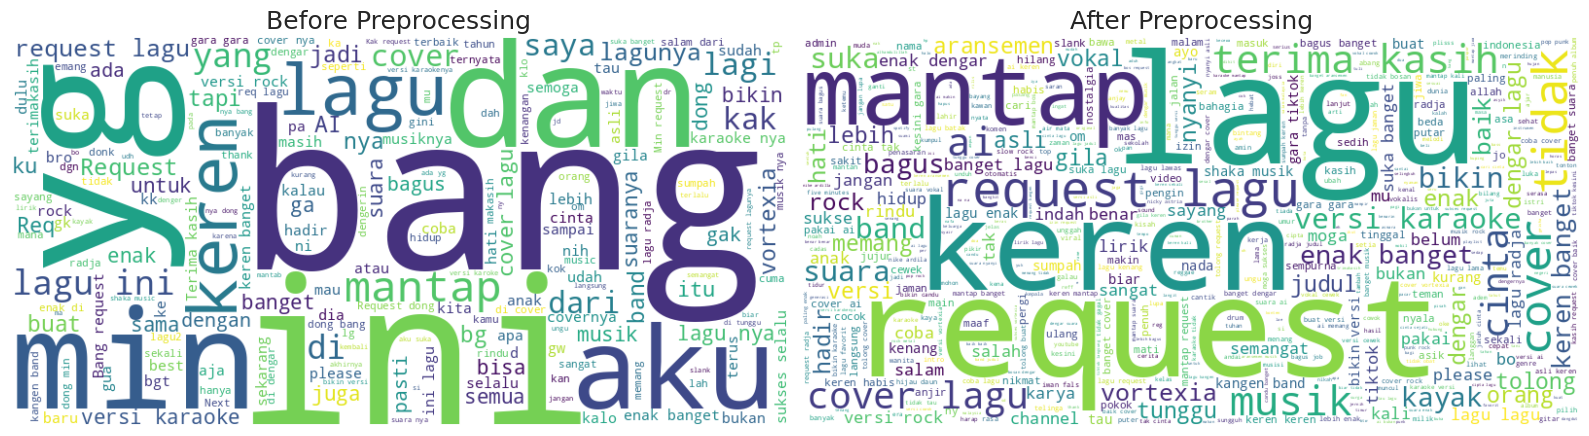

In [ ]:
wc_stopwords = set(STOPWORDS)
wc_stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh',
    'fyp', 'ya', 'gue', 'sih'
])

text_before = ' '.join(df_final['comment'].astype(str).tolist())
text_after  = ' '.join(df_final['stemming'].astype(str).tolist())

wc_before = WordCloud(
    stopwords=wc_stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_before)

wc_after = WordCloud(
    stopwords=wc_stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text_after)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()


**BAR CHART FREKUENSI KATA BEFORE & AFTER**

=== TOP 50 KATA SEBELUM PREPROCESSING ===
       Kata  Frekuensi
1      lagu       4993
2        di       2967
3       ini       2934
4        yg       2313
5      bang       2046
6      yang       1874
7     cover       1718
8     versi       1624
9   Request       1442
10      dan       1440
11      aku       1384
12        -       1279
13  request       1219
14     dari       1169
15    keren       1149
16      ada       1146
17     enak       1135
18     lagi        970
19     Lagu        909
20     band        896
21       AI        854
22    cinta        819
23     buat        802
24     bisa        801
25  lagunya        793
26     rock        765
27    Keren        750
28      tak        730
29     saya        693
30     Bang        657
31    suara        650
32     suka        633
33   Mantap        612
34    musik        611
35   mantap        610
36     sama        604
37    bikin        598
38  karaoke        596
39     jadi        561
40      Req        529
41      itu    

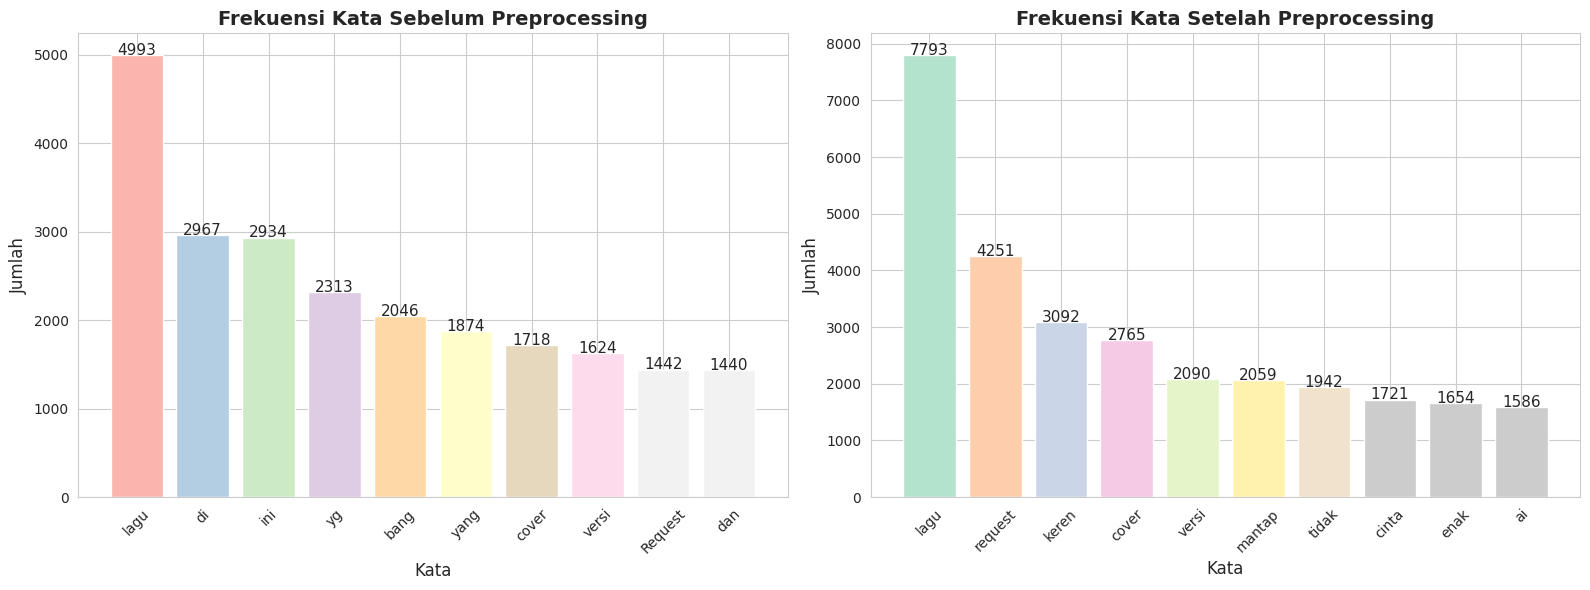

In [ ]:
bar_stopwords = set(STOPWORDS)
bar_stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp',
    'ya', 'gue', 'sih', 'kak', 'nya', 'nih', 'dong', 'aja',
    'lah', 'mah', 'kok', 'pun', 'tuh', 'kah', 'abang',
    'ku', 'kau', 'min', 'banget'
])

def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE
all_text_before = clean_text_column(df_final['comment'])
words_before = all_text_before.split()
filtered_before = [w for w in words_before if w.lower() not in bar_stopwords]
top_before = Counter(filtered_before).most_common(10)
word_before, count_before = zip(*top_before)

# AFTER
all_text_after = clean_text_column(df_final['stemming'])
words_after = all_text_after.split()
filtered_after = [w for w in words_after if w.lower() not in bar_stopwords]
top_after = Counter(filtered_after).most_common(10)
word_after, count_after = zip(*top_after)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 1,
                 str(cnt), ha='center', fontsize=11)

colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, cnt + 1,
                 str(cnt), ha='center', fontsize=11)

plt.tight_layout()
# TABEL FREKUENSI KATA

# Ambil top 50 kata before dan after
top_before_full = Counter(filtered_before).most_common(50)
top_after_full  = Counter(filtered_after).most_common(50)

df_freq_before = pd.DataFrame(top_before_full, columns=['Kata', 'Frekuensi'])
df_freq_before.index = df_freq_before.index + 1

df_freq_after = pd.DataFrame(top_after_full, columns=['Kata', 'Frekuensi'])
df_freq_after.index = df_freq_after.index + 1

print("=== TOP 50 KATA SEBELUM PREPROCESSING ===")
print(df_freq_before.to_string())

print("\n=== TOP 50 KATA SETELAH PREPROCESSING ===")
print(df_freq_after.to_string())

# Simpan ke CSV
df_freq_before.to_csv('frekuensi_kata_sebelum.csv', encoding='utf-8-sig', index=True)
df_freq_after.to_csv('frekuensi_kata_sesudah.csv', encoding='utf-8-sig', index=True)
print("\n✅ Tabel frekuensi tersimpan ke CSV")
plt.show()

**SIMPAN KE CSV**

---



In [ ]:
df_final.to_csv('Hasil_Preprocessing_Data.csv', encoding='utf-8-sig', index=False)
print()
print("✅ File Hasil_Preprocessing_Data.csv berhasil disimpan")

from google.colab import files
files.download('Hasil_Preprocessing_Data.csv')


✅ File Hasil_Preprocessing_Data.csv berhasil disimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Aspect-based Sentiment Classification (ABSC)***

**Load & Merge Data**

---




In [ ]:
# CELL 1: LOAD DATA HASIL PREPROCESSING

import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data = data.dropna(subset=['stemming'])
data = data[data['stemming'].str.strip() != ''].reset_index(drop=True)

print(f"Total komentar hasil preprocessing : {len(data)}")
data.head(5)

Total komentar hasil preprocessing : 26738


,comment,cleaning,case_folding,normalisasi,tokenisasi,stopword_removal,stemming,Unnamed: 7,Unnamed: 8
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,Suka dengan nuansa galau di lagu Aishiteru in...,suka dengan nuansa galau di lagu aishiteru in...,suka dengan nuansa galau di lagu aishiteru ini...,"['suka', 'dengan', 'nuansa', 'galau', 'di', 'l...",suka nuansa galau lagu aishiteru wajib dengar ...,suka nuansa galau lagu aishiteru wajib dengar ...,NaN,NaN
1,SALAM KENAL COVER AI,SALAM KENAL COVER AI,salam kenal cover ai,salam kenal cover ai,"['salam', 'kenal', 'cover', 'ai']",salam kenal cover ai,salam kenal cover ai,NaN,NaN
2,Babak. ❤❤❤❤. Vegi,Babak Vegi,babak vegi,babak vegi,"['babak', 'vegi']",babak vegi,babak vegi,NaN,NaN
3,Lagu AI Adalah Sampah Digital yang di oplos da...,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,lagu ai adalah sampah digital yang di oplos da...,"['lagu', 'ai', 'adalah', 'sampah', 'digital', ...",lagu ai sampah digital oplos tangan kotor krea...,lagu ai sampah digital oplos tangan kotor krea...,NaN,NaN
4,Cinta dihati \nOrang tua disurga😢,Cinta dihati Orang tua disurga,cinta dihati orang tua disurga,cinta dihati orang tua disurga,"['cinta', 'dihati', 'orang', 'tua', 'disurga']",cinta dihati orang tua disurga,cinta hati orang tua surga,NaN,NaN


**Definisi Keyword Aspek**

---




In [ ]:
aspect_keywords = {

    "Aktivitas Pendengar": [
        "request", "requestan", "karaoke", "ulang", "putar",
        "puter", "dengar", "nyanyi", "playlist",
        "streaming", "unduh", "repeat", "viral", "coverin",
        "kasih"
    ],

    "Kualitas Musik & Audio": [
        "suara", "musik", "aransemen", "rock", "vokal",
        "lirik", "nada", "jiwa", "beat", "melodi",
        "melody", "harmoni", "pitch", "bass", "mixing",
        "mastering", "merdu", "fals", "serak",
        "instrumen", "audio", "gitar", "drum",
        "biola", "chord", "tempo", "cengkok",
        "notasi", "note", "efek"
    ],

    "Konten & Teknologi AI": [
        "ai", "cover", "versi", "asli",
        "karya", "vortexia", "radja",
        "shaka", "teknologi", "artificial",
        "hak", "royalti", "cipta", "langgar",
        "suno"
    ],

    "Penilaian & Opini": [
        "keren", "mantap", "enak", "suka", "bagus",
        "gila", "candu", "asik", "asyik", "cocok",
        "seram", "merinding", "jos", "favorit",
        "bosan", "jelek", "buruk", "parah",
        "kecewa", "hati", "semangat",
        "sayang", "nostalgia", "terharu", "bahagia",
        "sedih", "wow", "dahsyat", "sempurna",
        "mewah", "syahdu", "adem", "nyala",
        "sukses", "top", "cakep", "nikmat",
        "sedap", "gurih", "indah", "kangen",
        "anjir", "oke", "power", "fresh",
        "segar", "jempol", "emosi", "mewek",
        "cadas", "rapi", "hebat", "manis",
        "lembut", "nyaman", "sentuh", "fine"
    ],
}

**Fungsi Ekstraksi Aspek label**

---



In [ ]:
from tqdm import tqdm

def extract_aspect(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'Tidak Terdeteksi'
    text = text.lower()
    for aspek, keywords in aspect_keywords.items():
        for keyword in keywords:
            if keyword in text:
                return aspek
    return 'Tidak Terdeteksi'

tqdm.pandas(desc="Ekstraksi Aspek")

data['aspek'] = data['stemming'].progress_apply(extract_aspect)

print(f"Total komentar : {len(data)}")
print(f"\nDistribusi per aspek (sebelum labeling sentimen):")
for aspek, count in data['aspek'].value_counts().items():
    persen = count / len(data) * 100
    print(f"  {aspek:<35} : {count:>5} ({persen:.2f}%)")

data[['comment', 'stemming', 'aspek']].head(10)

Ekstraksi Aspek: 100%|██████████| 26738/26738 [00:00<00:00, 172587.15it/s]

Total komentar : 26738

Distribusi per aspek (sebelum labeling sentimen):
  Aktivitas Pendengar                 :  8241 (30.82%)
  Tidak Terdeteksi                    :  5868 (21.95%)
  Penilaian & Opini                   :  4602 (17.21%)
  Konten & Teknologi AI               :  4266 (15.95%)
  Kualitas Musik & Audio              :  3761 (14.07%)


,comment,stemming,aspek
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka nuansa galau lagu aishiteru wajib dengar ...,Aktivitas Pendengar
1,SALAM KENAL COVER AI,salam kenal cover ai,Konten & Teknologi AI
2,Babak. ❤❤❤❤. Vegi,babak vegi,Tidak Terdeteksi
3,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai sampah digital oplos tangan kotor krea...,Aktivitas Pendengar
4,Cinta dihati \nOrang tua disurga😢,cinta hati orang tua surga,Penilaian & Opini
5,Cara bikin ai gini gimana bg 2:12,bikin ai,Konten & Teknologi AI
6,Cinta tidak direstui min. Udah like subscribe...,cinta tidak restu suka langgan,Penilaian & Opini
7,"Pejamkan mata di malam yang sepi, teringat mem...",pejam mata malam sepi memori,Tidak Terdeteksi
8,Request dong lagu dhot design menjauh,request lagu dhot design jauh,Aktivitas Pendengar
9,Ai merubah segalanya,ai rubah,Konten & Teknologi AI


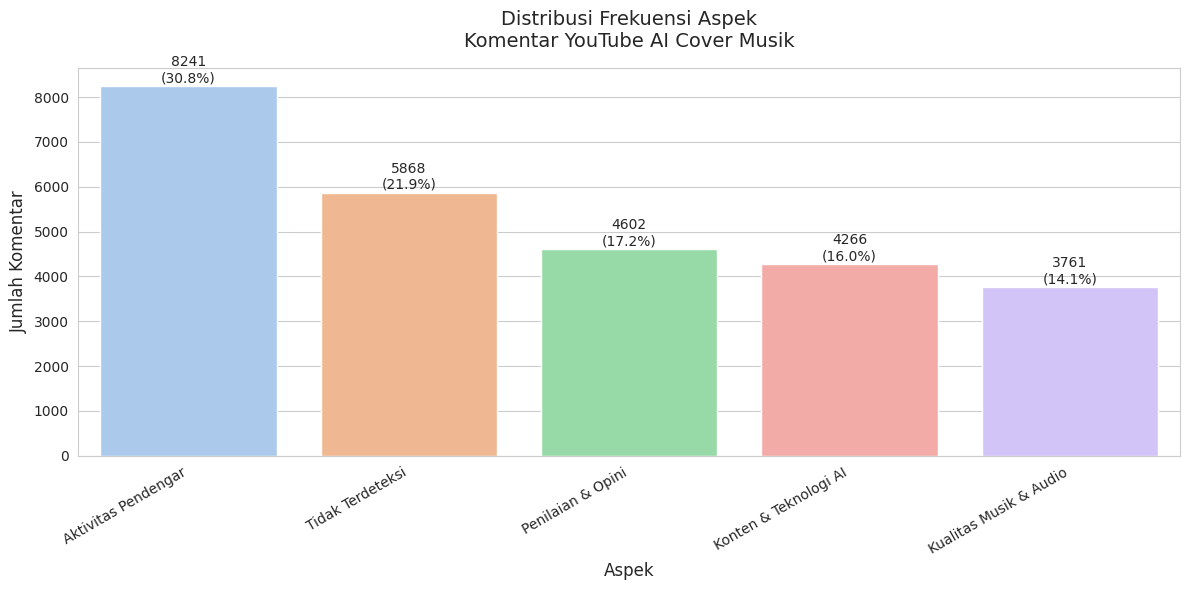

Grafik tersimpan: distribusi_aspek.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# df_viz = data[data['aspek'] != 'Tidak Terdeteksi']
aspek_counts = data['aspek'].value_counts()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=aspek_counts.index,
    y=aspek_counts.values,
    palette='pastel',
    ax=ax
)

plt.title('Distribusi Frekuensi Aspek\nKomentar YouTube AI Cover Musik',
          fontsize=14, pad=15)
plt.xlabel('Aspek', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.xticks(rotation=30, ha='right')

total = aspek_counts.sum()
for i, (aspek, count) in enumerate(aspek_counts.items()):
    persen = f'{100 * count / total:.1f}%'
    ax.text(i, count + 20, f'{count}\n({persen})',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: distribusi_aspek.png")

**Simpan Hasil**

In [ ]:
data[['comment', 'stemming', 'aspek']].to_csv(
    'Data_Beraspek.csv', encoding='utf-8-sig', index=False
)
print(f"File tersimpan: Data_Beraspek.csv ({len(data)} baris)")

from google.colab import files
files.download('Data_Beraspek.csv')

File tersimpan: Data_Beraspek.csv (26738 baris)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Labeling Sentimen***

**Load Data & Model**

In [ ]:
import pandas as pd
from transformers import pipeline
from tqdm.auto import tqdm

# Muat data yang SUDAH memiliki kolom aspek (bukan langsung dari preprocessing)
data = pd.read_csv("Data_Beraspek.csv")
data = data.dropna(subset=['stemming'])
data = data[data['stemming'].str.strip() != ''].reset_index(drop=True)

# Pertahankan kolom comment, stemming, dan aspek
data = data[['comment', 'stemming', 'aspek']].copy()

print(f"Total data siap dilabeli : {len(data)}")
data.head(5)

Total data siap dilabeli : 26738


,comment,stemming,aspek
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka nuansa galau lagu aishiteru wajib dengar ...,Aktivitas Pendengar
1,SALAM KENAL COVER AI,salam kenal cover ai,Konten & Teknologi AI
2,Babak. ❤❤❤❤. Vegi,babak vegi,Tidak Terdeteksi
3,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai sampah digital oplos tangan kotor krea...,Aktivitas Pendengar
4,Cinta dihati \nOrang tua disurga😢,cinta hati orang tua surga,Penilaian & Opini


**Fungsi Labeling & Eksekusi**

---



In [ ]:
# Load model RoBERTa IndoBERT
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

def chunk_text(text, max_len=512):
    return [text[i:i+max_len] for i in range(0, len(text), max_len)]

def roberta_sentiment(text):
    text = str(text)
    chunks = chunk_text(text)
    results  = [sentiment_pipeline(chunk)[0] for chunk in chunks]
    labels   = [r["label"] for r in results]
    scores   = [r["score"] for r in results]
    final_label = max(set(labels), key=labels.count)
    final_score = sum(scores) / len(scores)
    return {"label": final_label, "score": round(final_score, 4)}

tqdm.pandas(desc="Labeling RoBERTa")
results = data["stemming"].progress_apply(roberta_sentiment)

data["label_roberta"] = results.apply(lambda x: x["label"])
data["score_roberta"] = results.apply(lambda x: x["score"])

print(f"\nDistribusi label otomatis:")
print(data["label_roberta"].value_counts())
print(f"\nPersentase:")
print(data["label_roberta"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
data.head(10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Labeling RoBERTa:   0%|          | 0/26738 [00:00<?, ?it/s]


Distribusi label otomatis:
label_roberta
neutral     10038
positive     9573
negative     7127
Name: count, dtype: int64

Persentase:
label_roberta
neutral     37.54%
positive     35.8%
negative    26.65%
Name: proportion, dtype: object


,comment,stemming,aspek,label_roberta,score_roberta
0,Suka dengan nuansa galau di lagu Aishiteru 2 i...,suka nuansa galau lagu aishiteru wajib dengar ...,Aktivitas Pendengar,neutral,0.5340
1,SALAM KENAL COVER AI,salam kenal cover ai,Konten & Teknologi AI,neutral,0.9382
2,Babak. ❤❤❤❤. Vegi,babak vegi,Tidak Terdeteksi,negative,0.8636
3,Lagu AI Adalah Sampah Digital yang di oplos da...,lagu ai sampah digital oplos tangan kotor krea...,Aktivitas Pendengar,negative,0.9916
4,Cinta dihati \nOrang tua disurga😢,cinta hati orang tua surga,Penilaian & Opini,positive,0.7752
5,Cara bikin ai gini gimana bg 2:12,bikin ai,Konten & Teknologi AI,negative,0.4927
6,Cinta tidak direstui min. Udah like subscribe...,cinta tidak restu suka langgan,Penilaian & Opini,negative,0.9984
7,"Pejamkan mata di malam yang sepi, teringat mem...",pejam mata malam sepi memori,Tidak Terdeteksi,negative,0.9688
8,Request dong lagu dhot design menjauh,request lagu dhot design jauh,Aktivitas Pendengar,neutral,0.8978
9,Ai merubah segalanya,ai rubah,Konten & Teknologi AI,negative,0.8834


**Simpan untuk Validasi Manual**

In [ ]:
data_validasi = data[['comment', 'stemming', 'aspek', 'label_roberta', 'score_roberta']].copy()

# Tambahkan kolom kosong untuk diisi
data_validasi['label_manual'] = ''

data_validasi.to_csv('Data_Validasi_Manual.csv', encoding='utf-8-sig', index=False)
print(f"File Data_Validasi_Manual.csv tersimpan ({len(data_validasi)} baris)")
print()
print("Instruksi validasi manual:")
print("1. Buka file Data_Validasi_Manual.csv di Excel atau Google Sheets")
print("2. Baca kolom 'comment' asli")
print("3. Isi kolom 'label_manual' dengan: positive / negative / neutral")
print("4. Simpan kembali dengan nama: Data_Validasi_Manual_corrected.csv")

from google.colab import files
files.download('Data_Validasi_Manual.csv')

File Data_Validasi_Manual.csv tersimpan (26738 baris)

Instruksi validasi manual:
1. Buka file Data_Validasi_Manual.csv di Excel atau Google Sheets
2. Baca kolom 'comment' asli
3. Isi kolom 'label_manual' dengan: positive / negative / neutral
4. Simpan kembali dengan nama: Data_Validasi_Manual_corrected.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Load Hasil Validasi Manual**

In [ ]:
# LOAD HASIL VALIDASI MANUAL

import pandas as pd
from google.colab import files

print("Upload file Data_Validasi_Manual_corrected.csv hasil validasi manual Anda")
files.upload()

data_final = pd.read_csv('Data_Validasi_Manual_corrected.csv')

# Kalau label_manual kosong, gunakan label_roberta sebagai default
data_final['label_final'] = data_final.apply(
    lambda row: row['label_manual'].strip().lower()
    if isinstance(row['label_manual'], str) and row['label_manual'].strip() != ''
    else row['label_roberta'],
    axis=1
)

# Normalisasi label
data_final['label_final'] = data_final['label_final'].str.lower().str.strip()

# Validasi isi label
valid_labels = {'positive', 'negative', 'neutral'}
invalid = data_final[~data_final['label_final'].isin(valid_labels)]
if len(invalid) > 0:
    print(f"Ada {len(invalid)} baris dengan label tidak valid:")
    print(invalid['label_final'].unique())
else:
    print("Semua label valid")

# Hitung berapa yang dikoreksi manual
label_manual_clean = data_final['label_manual'].fillna('').astype(str).str.strip().str.lower()
label_roberta_clean = data_final['label_roberta'].fillna('').astype(str).str.strip().str.lower()

dikoreksi = data_final[
    (label_manual_clean != '') &
    (label_manual_clean != label_roberta_clean)
]

print(f"\nTotal data           : {len(data_final)}")
print(f"Dikoreksi manual     : {len(dikoreksi)}")
print(f"Mengikuti RoBERTa    : {len(data_final) - len(dikoreksi)}")
print(f"\nDistribusi label final:")
print(data_final['label_final'].value_counts())
print(f"\nPersentase:")
print(data_final['label_final'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Upload file Data_Validasi_Manual_corrected.csv hasil validasi manual Anda


Saving Data_Validasi_Manual_corrected.csv to Data_Validasi_Manual_corrected (1).csv
Semua label valid

Total data           : 26738
Dikoreksi manual     : 9017
Mengikuti RoBERTa    : 17721

Distribusi label final:
label_final
neutral     16959
positive     9236
negative      543
Name: count, dtype: int64

Persentase:
label_final
neutral     63.43%
positive    34.54%
negative     2.03%
Name: proportion, dtype: object


**Visualisasi Label Final**

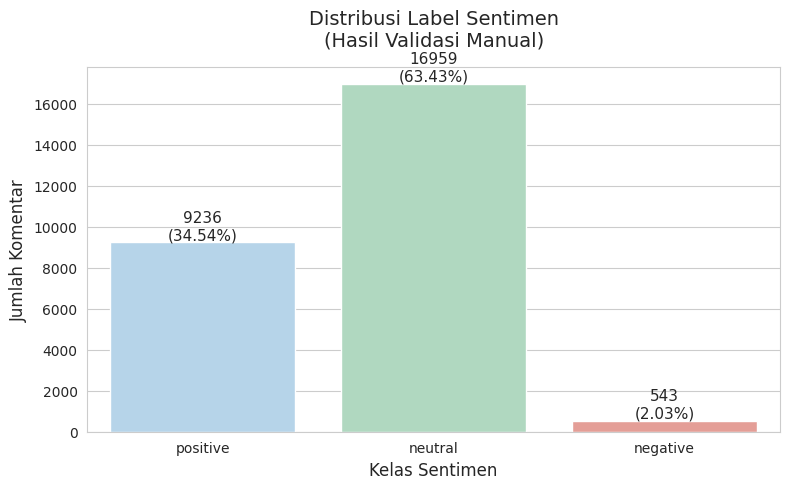

Grafik tersimpan: distribusi_label_sentimen.png


In [ ]:
# VISUALISASI DISTRIBUSI LABEL FINAL

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

label_counts = data_final['label_final'].value_counts()
label_order  = ['positive', 'neutral', 'negative']
label_counts = label_counts.reindex(label_order)

palette = {
    'positive': '#AED6F1',
    'neutral' : '#A9DFBF',
    'negative': '#F1948A'
}

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette=palette,
    order=label_order,
    ax=ax
)

plt.title('Distribusi Label Sentimen\n(Hasil Validasi Manual)', fontsize=14, pad=15)
plt.xlabel('Kelas Sentimen', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)

total = len(data_final)
for i, (label, count) in enumerate(zip(label_order, label_counts.values)):
    persen = f'{100 * count / total:.2f}%'
    ax.text(i, count + 20, f'{count}\n({persen})', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('distribusi_label_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: distribusi_label_sentimen.png")

**Filter data Netral**

---



In [ ]:
# FILTER DATA NETRAL
# Kolom 'aspek' tetap ada karena sudah dibawa sejak awal (Cell 1 Labeling Sentimen).

sebelum = len(data_final)
data_final = data_final[data_final['label_final'] != 'neutral'].reset_index(drop=True)
sesudah = len(data_final)

print(f"Sebelum filter netral : {sebelum}")
print(f"Sesudah filter netral : {sesudah}")
print(f"Data netral dibuang   : {sebelum - sesudah}")
print(f"\nDistribusi label setelah filter:")
for label, count in data_final['label_final'].value_counts().items():
    persen = count / len(data_final) * 100
    print(f"  {label:<12} : {count:>5} ({persen:.2f}%)")

print(f"\nDistribusi aspek pada data akhir (setelah netral dibuang):")
for aspek, count in data_final['aspek'].value_counts().items():
    persen = count / len(data_final) * 100
    print(f"  {aspek:<35} : {count:>5} ({persen:.2f}%)")

Sebelum filter netral : 26738
Sesudah filter netral : 9779
Data netral dibuang   : 16959

Distribusi label setelah filter:
  positive     :  9236 (94.45%)
  negative     :   543 (5.55%)

Distribusi aspek pada data akhir (setelah netral dibuang):
  Konten & Teknologi AI               :  2815 (28.79%)
  Penilaian & Opini                   :  2571 (26.29%)
  Kualitas Musik & Audio              :  2364 (24.17%)
  Aktivitas Pendengar                 :  1630 (16.67%)
  Tidak Terdeteksi                    :   399 (4.08%)


**Wordcloud sentimen**

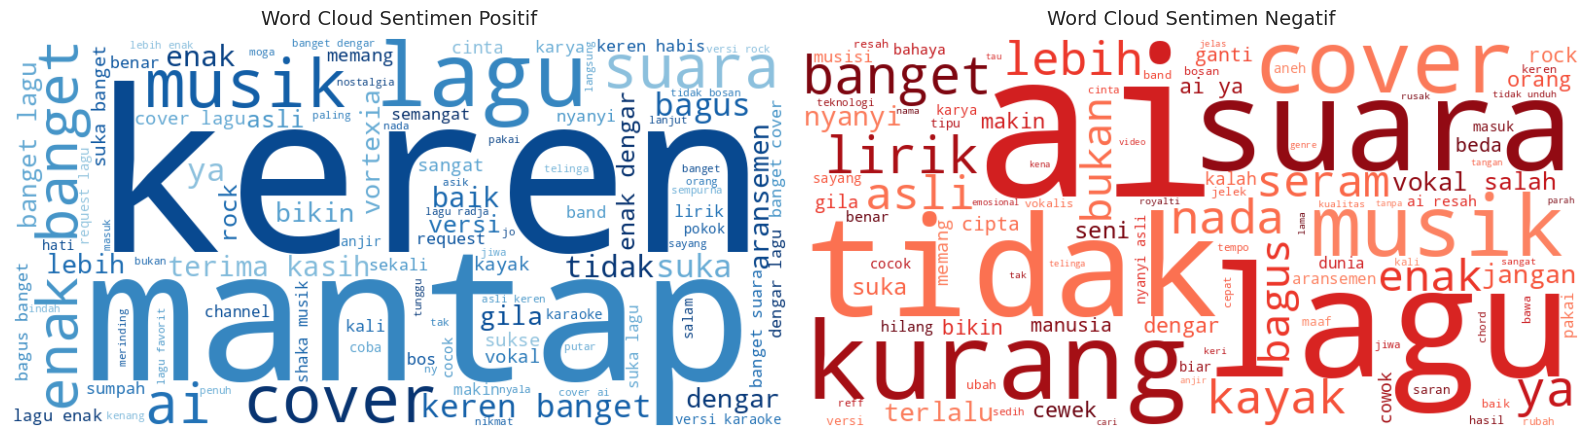

Grafik tersimpan: wordcloud_sentimen.png


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Potong colormap agar hanya mengambil warna yang pekat/gelap
colors_positive = plt.cm.Blues(np.linspace(0.4, 1.0, 256)) # Mulai dari 0.4 agar tidak ada warna putih/muda
colors_negative = plt.cm.Reds(np.linspace(0.4, 1.0, 256))

# 2. Buat colormap baru dari warna yang sudah dipotong
cmap_positive = mcolors.ListedColormap(colors_positive)
cmap_negative = mcolors.ListedColormap(colors_negative)

positive_text = ' '.join(data_final[data_final['label_final'] == 'positive']['stemming'].dropna())
negative_text = ' '.join(data_final[data_final['label_final'] == 'negative']['stemming'].dropna())

# 3. Masukkan colormap baru ke dalam WordCloud
wc_positive = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap=cmap_positive,  # Menggunakan cmap kustom
    max_words=100
).generate(positive_text)

wc_negative = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap=cmap_negative,  # Menggunakan cmap kustom
    max_words=100
).generate(negative_text)

# --- Sisa kode plot Anda ke bawah tetap sama ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud Sentimen Positif', fontsize=14, pad=10)

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud Sentimen Negatif', fontsize=14, pad=10)

plt.tight_layout()
plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: wordcloud_sentimen.png")

In [ ]:
# DISTRIBUSI SENTIMEN PER ASPEK

df_sentimen_aspek = data_final.groupby(
    ['aspek', 'label_final']
).size().reset_index(name='jumlah')

df_sentimen_aspek['total_aspek'] = df_sentimen_aspek.groupby(
    'aspek')['jumlah'].transform('sum')
df_sentimen_aspek['persentase'] = (
    df_sentimen_aspek['jumlah'] / df_sentimen_aspek['total_aspek'] * 100
).round(2)

print("=== DISTRIBUSI SENTIMEN PER ASPEK ===\n")
aspek_order_print = data_final[data_final['aspek'] != 'Tidak Terdeteksi']['aspek'].value_counts().index.tolist()
aspek_order_print.append('Tidak Terdeteksi')

for aspek in aspek_order_print:
    subset = df_sentimen_aspek[df_sentimen_aspek['aspek'] == aspek]
    if subset.empty:
        continue
    print(f"{aspek}")
    print("-" * 45)
    for _, row in subset.iterrows():
        print(f"  {row['label_final']:<12} : {row['jumlah']:>5} ({row['persentase']}%)")
    print()

=== DISTRIBUSI SENTIMEN PER ASPEK ===

Konten & Teknologi AI
---------------------------------------------
  negative     :   196 (6.96%)
  positive     :  2619 (93.04%)

Penilaian & Opini
---------------------------------------------
  negative     :    29 (1.13%)
  positive     :  2542 (98.87%)

Kualitas Musik & Audio
---------------------------------------------
  negative     :   212 (8.97%)
  positive     :  2152 (91.03%)

Aktivitas Pendengar
---------------------------------------------
  negative     :    69 (4.23%)
  positive     :  1561 (95.77%)

Tidak Terdeteksi
---------------------------------------------
  negative     :    37 (9.27%)
  positive     :   362 (90.73%)



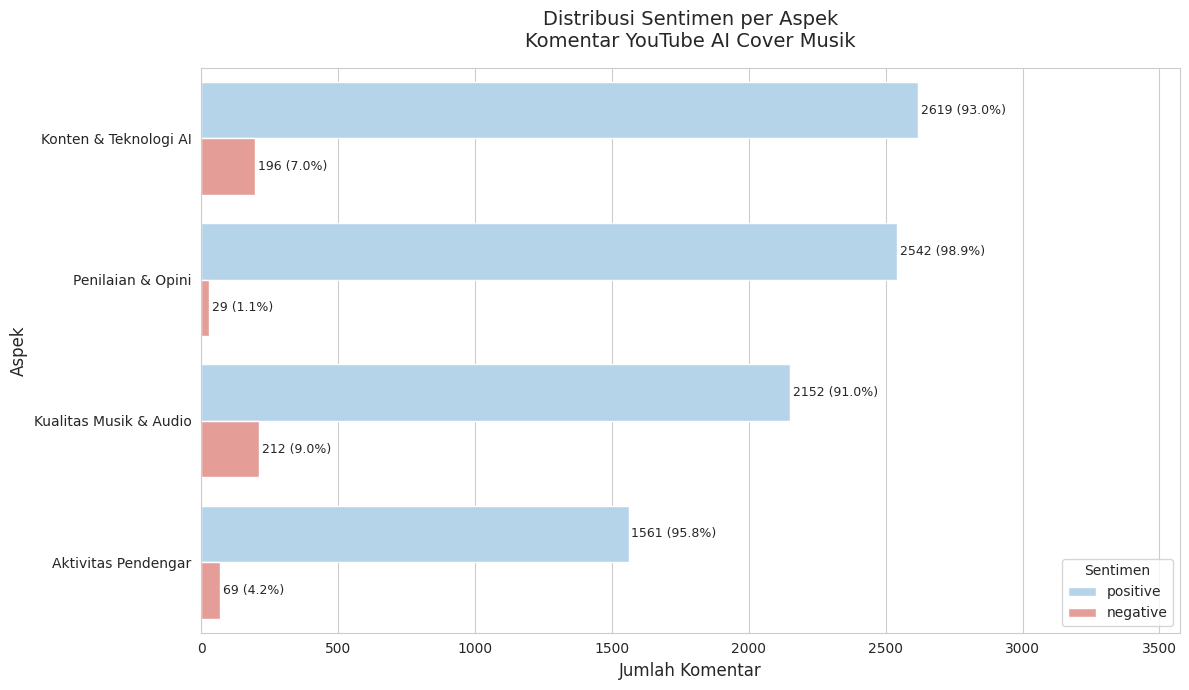

Grafik tersimpan: sentimen_per_aspek.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df_viz2 = data_final[data_final['aspek'] != 'Tidak Terdeteksi'].copy()

palette_sentimen = {
    'positive': '#AED6F1',
    'negative': '#F1948A'
}

aspek_order  = df_viz2['aspek'].value_counts().index.tolist()
sentimen_order = ['positive', 'negative']
total_per_aspek = df_viz2.groupby('aspek').size().to_dict()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

sns.countplot(
    data=df_viz2,
    y='aspek',
    hue='label_final',
    palette=palette_sentimen,
    order=aspek_order,
    hue_order=sentimen_order,
    ax=ax
)

for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        aspek_idx = int(bar.get_y() + bar.get_height() / 2 + 0.5)
        if aspek_idx < len(aspek_order):
            aspek_nama  = aspek_order[aspek_idx]
            total_aspek = total_per_aspek.get(aspek_nama, 1)
            persen = f'{100 * width / total_aspek:.1f}%'
            ax.text(
                width + 10,
                bar.get_y() + bar.get_height() / 2,
                f'{int(width)} ({persen})',
                va='center', ha='left', fontsize=9
            )

plt.title('Distribusi Sentimen per Aspek\nKomentar YouTube AI Cover Musik',
          fontsize=14, pad=15)
plt.xlabel('Jumlah Komentar', fontsize=12)
plt.ylabel('Aspek', fontsize=12)
plt.legend(title='Sentimen', loc='lower right')
ax.set_xlim(0, ax.get_xlim()[1] * 1.3)

plt.tight_layout()
plt.savefig('sentimen_per_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: sentimen_per_aspek.png")

**Simpan Data Final**

In [ ]:
# SIMPAN HASIL AKHIR (siap untuk TF-IDF & Logistic Regression)

from google.colab import files

data_final[['comment', 'stemming', 'label_final', 'aspek']].to_csv(
    'Hasil_ABSA.csv', encoding='utf-8-sig', index=False
)

df_sentimen_aspek.to_csv(
    'Ringkasan_Sentimen_Aspek.csv', encoding='utf-8-sig', index=False
)

df_distribusi = data_final['aspek'].value_counts().reset_index()
df_distribusi.columns = ['Aspek', 'Jumlah']
df_distribusi['Persentase'] = (
    df_distribusi['Jumlah'] / len(data_final) * 100
).round(2)
df_distribusi.to_csv(
    'Distribusi_Aspek.csv', encoding='utf-8-sig', index=False
)

data_final[['comment', 'stemming', 'label_final']].to_csv(
    'Hasil_Labeling_Final.csv', encoding='utf-8-sig', index=False
)

print("File tersimpan:")
print(f"   Hasil_ABSA.csv                ({len(data_final)} baris)")
print(f"   Ringkasan_Sentimen_Aspek.csv  ({len(df_sentimen_aspek)} baris)")
print(f"   Distribusi_Aspek.csv          ({len(df_distribusi)} baris)")
print(f"   Hasil_Labeling_Final.csv      ({len(data_final)} baris)")
print()
print("=== RINGKASAN FINAL ===")
for _, row in df_distribusi.iterrows():
    print(f"  {row['Aspek']:<35} : {row['Jumlah']:>5} ({row['Persentase']}%)")

files.download('Hasil_ABSA.csv')
files.download('Ringkasan_Sentimen_Aspek.csv')
files.download('Distribusi_Aspek.csv')
files.download('Hasil_Labeling_Final.csv')

File tersimpan:
   Hasil_ABSA.csv                (9779 baris)
   Ringkasan_Sentimen_Aspek.csv  (10 baris)
   Distribusi_Aspek.csv          (5 baris)
   Hasil_Labeling_Final.csv      (9779 baris)

=== RINGKASAN FINAL ===
  Konten & Teknologi AI               :  2815 (28.79%)
  Penilaian & Opini                   :  2571 (26.29%)
  Kualitas Musik & Audio              :  2364 (24.17%)
  Aktivitas Pendengar                 :  1630 (16.67%)
  Tidak Terdeteksi                    :   399 (4.08%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Modeling**

---

**Install & Import**

In [ ]:
# CELL 1: INSTALL & IMPORT

!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from IPython.display import display

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


**Load Data**

In [ ]:
# CELL 2: LOAD DATA

df = pd.read_csv('Hasil_ABSA.csv')
df = df.dropna(subset=['stemming', 'label_final', 'aspek'])
df = df[df['aspek'] != 'Tidak Terdeteksi'].reset_index(drop=True)

print(f"Total data : {len(df)}")
print(f"\nDistribusi per aspek:")
for aspek, count in df['aspek'].value_counts().items():
    subset = df[df['aspek'] == aspek]
    pos = len(subset[subset['label_final'] == 'positive'])
    neg = len(subset[subset['label_final'] == 'negative'])
    print(f"  {aspek:<35} : {count} (pos={pos}, neg={neg})")

    print(df.shape)

Total data : 9380

Distribusi per aspek:
  Konten & Teknologi AI               : 2815 (pos=2619, neg=196)
(9380, 4)
  Penilaian & Opini                   : 2571 (pos=2542, neg=29)
(9380, 4)
  Kualitas Musik & Audio              : 2364 (pos=2152, neg=212)
(9380, 4)
  Aktivitas Pendengar                 : 1630 (pos=1561, neg=69)
(9380, 4)


**TF-IDF**

In [ ]:
# CELL 3: TF-IDF VECTORIZER

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
print("✅ Vectorizer siap")
print(f"Konfigurasi: ngram_range=(1,2), min_df=2")

✅ Vectorizer siap
Konfigurasi: ngram_range=(1,2), min_df=2


**Split Data + TF-IDF per aspek**

In [ ]:
# CELL 5: SPLIT DATA + TF-IDF PER ASPEK

from sklearn.model_selection import train_test_split

data_aspek = {}
split_data = {}

for aspek in df['aspek'].unique():
    df_aspek = df[df['aspek'] == aspek]

    X_raw = df_aspek['stemming']
    y = df_aspek['label_final']

    # Split dulu sebelum TF-IDF
    X_raw_train, X_raw_test, y_train, y_test = train_test_split(
        X_raw, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    # Fit vectorizer HANYA pada data latih
    vectorizer_aspek = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    X_train = vectorizer_aspek.fit_transform(X_raw_train)
    X_test = vectorizer_aspek.transform(X_raw_test)

    split_data[aspek] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'vectorizer': vectorizer_aspek
    }

    data_aspek[aspek] = {
        'y_train': y_train,
        'y_test': y_test
    }

    print(f"{aspek}: Train={len(y_train)} | Test={len(y_test)} | Fitur={X_train.shape[1]}")

print(f"\n✅ Split dan TF-IDF per aspek selesai")

Aktivitas Pendengar: Train=1141 | Test=489 | Fitur=1332
Konten & Teknologi AI: Train=1970 | Test=845 | Fitur=1309
Kualitas Musik & Audio: Train=1654 | Test=710 | Fitur=1578
Penilaian & Opini: Train=1799 | Test=772 | Fitur=754

✅ Split dan TF-IDF per aspek selesai


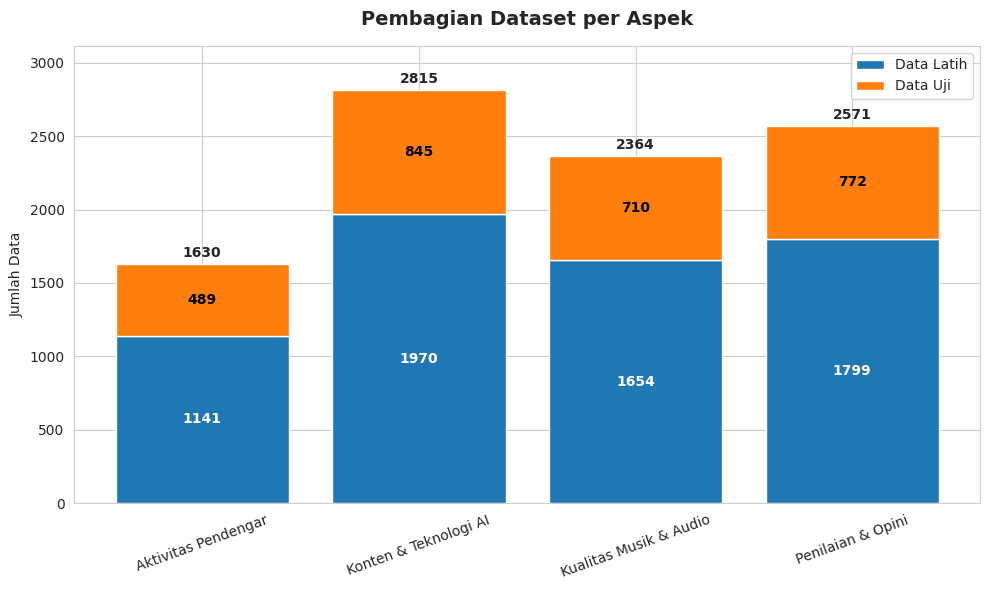

In [ ]:
# CELL 6 VISUALISASI SPLIT

import matplotlib.pyplot as plt

nama_aspek = []
jumlah_train = []
jumlah_test = []

for aspek, data in data_aspek.items():
    nama_aspek.append(aspek)
    jumlah_train.append(len(data['y_train']))
    jumlah_test.append(len(data['y_test']))

plt.figure(figsize=(10,6))

x = range(len(nama_aspek))

# Simpan objek bar ke dalam variabel untuk memberi label
bars_train = plt.bar(x, jumlah_train, label='Data Latih', color='#1f77b4')
bars_test = plt.bar(x, jumlah_test, bottom=jumlah_train, label='Data Uji', color='#ff7f0e')

# 1. Menambahkan label angka Data Latih (di tengah balok biru)
plt.bar_label(bars_train, label_type='center', color='white', fontweight='bold', fontsize=10)

# 2. Menambahkan label angka Data Uji (di tengah balok orange)
plt.bar_label(bars_test, label_type='center', color='black', fontweight='bold', fontsize=10)

# 3. Menambahkan label Total Data (di paling atas ujung balok)
plt.bar_label(bars_test, label_type='edge', padding=3, fontweight='bold', fontsize=10)

plt.xticks(x, nama_aspek, rotation=20)
plt.ylabel("Jumlah Data")
plt.title("Pembagian Dataset per Aspek", pad=15, fontsize=14, fontweight='bold')
plt.legend(loc='upper right')

# Memberikan ruang tambahan di atas diagram agar label nilai tertinggi tidak mepet grid
plt.ylim(0, max(jumlah_train) + max(jumlah_test) + 300)

plt.tight_layout()
plt.show()

## **Skenario 1 ML Tanpa SMOTE**

---



**Training**

In [ ]:
# SKENARIO 1: TRAINING LOGISTIC REGRESSION TANPA SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

hasil_no_smote = {}

for aspek in split_data.keys():
    X_train = split_data[aspek]['X_train']
    X_test  = split_data[aspek]['X_test']
    y_train = split_data[aspek]['y_train']
    y_test  = split_data[aspek]['y_test']

    model = LogisticRegression(max_iter=500, random_state=42)
    model.fit(X_train, y_train)

    y_pred    = model.predict(X_test)
    train_acc = model.score(X_train, y_train)
    test_acc  = accuracy_score(y_test, y_pred)
    selisih   = abs(train_acc - test_acc)

    label_order = ['negative', 'positive']
    report = classification_report(
        y_test, y_pred,
        labels=label_order,
        output_dict=True,
        zero_division=0
    )

    hasil_no_smote[aspek] = {
        'model'    : model,
        'y_test'   : y_test,
        'y_pred'   : y_pred,
        'train_acc': train_acc,
        'test_acc' : test_acc,
        'selisih'  : selisih,
        'report'   : report,
        'cm'       : confusion_matrix(y_test, y_pred, labels=label_order)
    }

    print(f"\n{'='*55}")
    print(f"  ASPEK: {aspek}")
    print(f"{'='*55}")
    print(f"  Akurasi latih : {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Akurasi uji   : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Selisih       : {selisih:.4f} {'⚠️ Perlu diperhatikan' if selisih > 0.05 else '✅ Stabil'}")
    print(classification_report(y_test, y_pred, labels=label_order, zero_division=0))

print(f"\n✅ Training selesai tanpa SMOTE ({len(hasil_no_smote)} aspek)")


  ASPEK: Aktivitas Pendengar
  Akurasi latih : 0.9579 (95.79%)
  Akurasi uji   : 0.9571 (95.71%)
  Selisih       : 0.0009 ✅ Stabil
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        21
    positive       0.96      1.00      0.98       468

    accuracy                           0.96       489
   macro avg       0.48      0.50      0.49       489
weighted avg       0.92      0.96      0.94       489


  ASPEK: Konten & Teknologi AI
  Akurasi latih : 0.9360 (93.60%)
  Akurasi uji   : 0.9408 (94.08%)
  Selisih       : 0.0048 ✅ Stabil
              precision    recall  f1-score   support

    negative       0.80      0.20      0.32        59
    positive       0.94      1.00      0.97       786

    accuracy                           0.94       845
   macro avg       0.87      0.60      0.65       845
weighted avg       0.93      0.94      0.92       845


  ASPEK: Kualitas Musik & Audio
  Akurasi latih : 0.9353 (93.53%)
  Akurasi uji

### **Evaluasi Model**

**Confusion matrix**

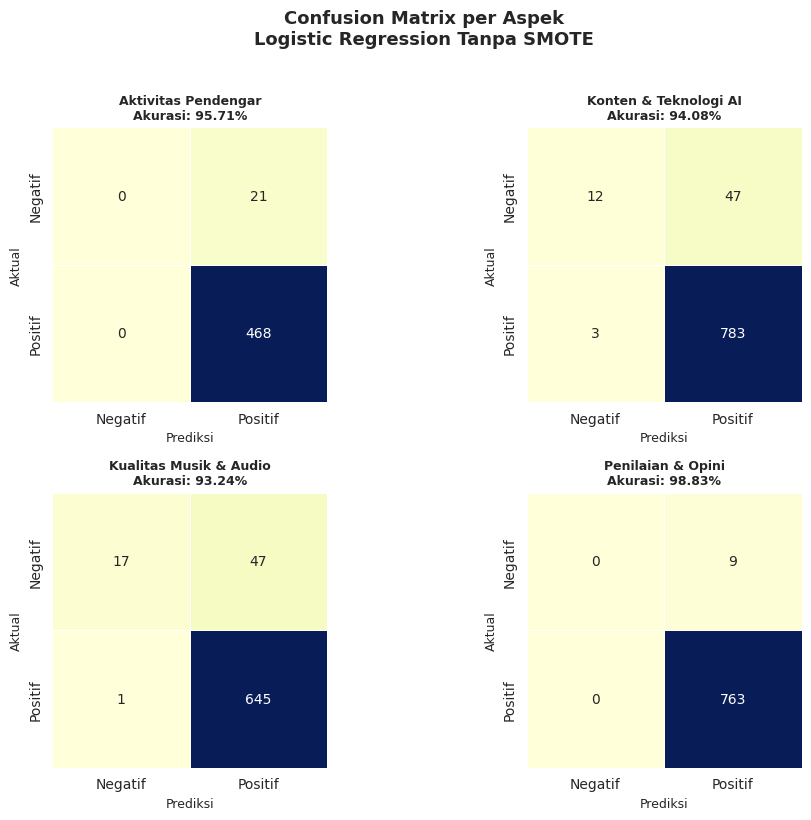

✅ confusion_matrix_tanpa_smote.png tersimpan dengan format 2 baris


In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# CONFUSION MATRIX TANPA SMOTE (2 BARIS)

label_indo = ['Negatif', 'Positif']
n_aspek = len(hasil_no_smote)

# Tentukan jumlah kolom berdasarkan target 2 baris
n_rows = 2
n_cols = math.ceil(n_aspek / n_rows)

# Buat subplot dengan format grid (n_rows x n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Tolong ratakan (flatten) axes agar mudah di-loop jika bentuknya matriks 2D
axes_flat = axes.flatten()

for i, (aspek, hasil) in enumerate(hasil_no_smote.items()):
    ax = axes_flat[i]
    sns.heatmap(
        hasil['cm'],
        annot=True, fmt='d', cmap='YlGnBu',
        cbar=False,
        xticklabels=label_indo,
        yticklabels=label_indo,
        ax=ax, square=True, linewidths=0.5
    )
    ax.set_title(
        f"{aspek}\nAkurasi: {hasil['test_acc']*100:.2f}%",
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)

# Menghapus/menyembunyikan sisa kotak subplot yang kosong jika jumlah aspek ganjil
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle(
    'Confusion Matrix per Aspek\nLogistic Regression Tanpa SMOTE',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrix_tanpa_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ confusion_matrix_tanpa_smote.png tersimpan dengan format 2 baris")

**Visualisasi Tabel Classification Report**

In [ ]:
# CELL 7: TABEL CLASSIFICATION REPORT PER ASPEK

from IPython.display import display

# Ganti hasil_no_smote dengan hasil_smote untuk versi SMOTE
hasil_dipakai = hasil_no_smote  # atau hasil_smote
judul_versi   = "Tanpa SMOTE"   # atau "Dengan SMOTE"

label_order = ['negative', 'positive']

print(f"=== CLASSIFICATION REPORT PER ASPEK ({judul_versi}) ===\n")

ringkasan_lengkap = []

for aspek, hasil in hasil_dipakai.items():
    print(f"\n--- {aspek} ---")
    report = hasil['report']

    # Tampilkan tabel per aspek
    df_report = pd.DataFrame({
        'Kelas'    : ['Negatif', 'Positif', 'Macro Avg', 'Weighted Avg'],
        'Precision': [
            round(report['negative']['precision'], 4),
            round(report['positive']['precision'], 4),
            round(report['macro avg']['precision'], 4),
            round(report['weighted avg']['precision'], 4),
        ],
        'Recall'   : [
            round(report['negative']['recall'], 4),
            round(report['positive']['recall'], 4),
            round(report['macro avg']['recall'], 4),
            round(report['weighted avg']['recall'], 4),
        ],
        'F1-Score' : [
            round(report['negative']['f1-score'], 4),
            round(report['positive']['f1-score'], 4),
            round(report['macro avg']['f1-score'], 4),
            round(report['weighted avg']['f1-score'], 4),
        ],
        'Support'  : [
            int(report['negative']['support']),
            int(report['positive']['support']),
            int(report['macro avg']['support']),
            int(report['weighted avg']['support']),
        ],
    })

    styled = df_report.style\
        .background_gradient(cmap='Blues',
                             subset=['Precision', 'Recall', 'F1-Score'])\
        .format({'Precision': '{:.4f}',
                 'Recall'   : '{:.4f}',
                 'F1-Score' : '{:.4f}',
                 'Support'  : '{:.0f}'})\
        .set_caption(f"Classification Report - {aspek}")
    display(styled)

    # Simpan untuk ringkasan keseluruhan
    ringkasan_lengkap.append({
        'Aspek'        : aspek,
        'Akurasi Test' : round(hasil['test_acc'], 4),
        'Precision (M)': round(report['macro avg']['precision'], 4),
        'Recall (M)'   : round(report['macro avg']['recall'], 4),
        'F1-Score (M)' : round(report['macro avg']['f1-score'], 4),
        'Precision (W)': round(report['weighted avg']['precision'], 4),
        'Recall (W)'   : round(report['weighted avg']['recall'], 4),
        'F1-Score (W)' : round(report['weighted avg']['f1-score'], 4),
    })

=== CLASSIFICATION REPORT PER ASPEK (Tanpa SMOTE) ===


--- Aktivitas Pendengar ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.0000,0.0000,0.0000,21
1,Positif,0.9571,1.0000,0.9781,468
2,Macro Avg,0.4785,0.5000,0.4890,489
3,Weighted Avg,0.9160,0.9571,0.9361,489



--- Konten & Teknologi AI ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.8000,0.2034,0.3243,59
1,Positif,0.9434,0.9962,0.9691,786
2,Macro Avg,0.8717,0.5998,0.6467,845
3,Weighted Avg,0.9334,0.9408,0.9240,845



--- Kualitas Musik & Audio ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.9444,0.2656,0.4146,64
1,Positif,0.9321,0.9985,0.9641,646
2,Macro Avg,0.9383,0.6320,0.6894,710
3,Weighted Avg,0.9332,0.9324,0.9146,710



--- Penilaian & Opini ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.0000,0.0000,0.0000,9
1,Positif,0.9883,1.0000,0.9941,763
2,Macro Avg,0.4942,0.5000,0.4971,772
3,Weighted Avg,0.9768,0.9883,0.9825,772


In [ ]:
# CELL 8: RINGKASAN KESELURUHAN SEMUA ASPEK

df_ringkasan = pd.DataFrame(ringkasan_lengkap)

print(f"=== RINGKASAN KESELURUHAN ({judul_versi}) ===\n")

# Tampilkan tabel bergradien
styled_ringkasan = df_ringkasan.style\
    .background_gradient(cmap='Blues',
                         subset=['Akurasi Test',
                                 'Precision (W)', 'Recall (W)', 'F1-Score (W)'])\
    .format({col: '{:.4f}' for col in df_ringkasan.columns if col != 'Aspek'})\
    .set_caption(f"Ringkasan Evaluasi per Aspek - {judul_versi}")
display(styled_ringkasan)

# Label-based accuracy per aspek dan rata-rata
print(f"\n=== LABEL-BASED ACCURACY ===")
semua_acc = []
for _, row in df_ringkasan.iterrows():
    acc = row['Akurasi Test']
    semua_acc.append(acc)
    print(f"  {row['Aspek']:<35} : {acc:.4f} ({acc*100:.2f}%)")

rata_rata = np.mean(semua_acc)
print(f"\n  {'Label-Based Accuracy (rata-rata)':<35} : {rata_rata:.4f} ({rata_rata*100:.2f}%)")

# Simpan CSV
df_ringkasan.to_csv(f'Ringkasan_{judul_versi.replace(" ", "_")}.csv',
                    encoding='utf-8-sig', index=False)
print(f"\n✅ Ringkasan_{judul_versi.replace(' ', '_')}.csv tersimpan")

from google.colab import files
files.download(f'Ringkasan_{judul_versi.replace(" ", "_")}.csv')

=== RINGKASAN KESELURUHAN (Tanpa SMOTE) ===



,Aspek,Akurasi Test,Precision (M),Recall (M),F1-Score (M),Precision (W),Recall (W),F1-Score (W)
0,Aktivitas Pendengar,0.9571,0.4785,0.5000,0.4890,0.9160,0.9571,0.9361
1,Konten & Teknologi AI,0.9408,0.8717,0.5998,0.6467,0.9334,0.9408,0.9240
2,Kualitas Musik & Audio,0.9324,0.9383,0.6320,0.6894,0.9332,0.9324,0.9146
3,Penilaian & Opini,0.9883,0.4942,0.5000,0.4971,0.9768,0.9883,0.9825



=== LABEL-BASED ACCURACY ===
  Aktivitas Pendengar                 : 0.9571 (95.71%)
  Konten & Teknologi AI               : 0.9408 (94.08%)
  Kualitas Musik & Audio              : 0.9324 (93.24%)
  Penilaian & Opini                   : 0.9883 (98.83%)

  Label-Based Accuracy (rata-rata)    : 0.9546 (95.47%)

✅ Ringkasan_Tanpa_SMOTE.csv tersimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# RINGKASAN TOTAL KESELURUHAN MODEL

print(f"\n=== TOTAL EVALUASI MODEL ({judul_versi}) ===\n")

total_precision_w = df_ringkasan['Precision (W)'].mean()
total_recall_w    = df_ringkasan['Recall (W)'].mean()
total_f1_w        = df_ringkasan['F1-Score (W)'].mean()
total_precision_m = df_ringkasan['Precision (M)'].mean()
total_recall_m    = df_ringkasan['Recall (M)'].mean()
total_f1_m        = df_ringkasan['F1-Score (M)'].mean()
total_akurasi     = df_ringkasan['Akurasi Test'].mean()

print(f"  Label-Based Accuracy (rata-rata)  : {total_akurasi:.4f} ({total_akurasi*100:.2f}%)")
print(f"  Precision  (Weighted Avg)          : {total_precision_w:.4f}")
print(f"  Recall     (Weighted Avg)          : {total_recall_w:.4f}")
print(f"  F1-Score   (Weighted Avg)          : {total_f1_w:.4f}")
print(f"  Precision  (Macro Avg)             : {total_precision_m:.4f}")
print(f"  Recall     (Macro Avg)             : {total_recall_m:.4f}")
print(f"  F1-Score   (Macro Avg)             : {total_f1_m:.4f}")

# Tampilkan tabel total
df_total = pd.DataFrame([{
    'Metrik'  : 'Keseluruhan Model',
    'Akurasi' : round(total_akurasi, 4),
    'Precision (W)': round(total_precision_w, 4),
    'Recall (W)'   : round(total_recall_w, 4),
    'F1-Score (W)' : round(total_f1_w, 4),
    'Precision (M)': round(total_precision_m, 4),
    'Recall (M)'   : round(total_recall_m, 4),
    'F1-Score (M)' : round(total_f1_m, 4),
}])

styled_total = df_total.style\
    .background_gradient(cmap='Greens',
                         subset=['Akurasi',
                                 'Precision (W)', 'Recall (W)', 'F1-Score (W)'])\
    .format({col: '{:.4f}' for col in df_total.columns if col != 'Metrik'})\
    .set_caption(f"Total Evaluasi Keseluruhan Model - {judul_versi}")
display(styled_total)


=== TOTAL EVALUASI MODEL (Tanpa SMOTE) ===

  Label-Based Accuracy (rata-rata)  : 0.9546 (95.47%)
  Precision  (Weighted Avg)          : 0.9399
  Recall     (Weighted Avg)          : 0.9546
  F1-Score   (Weighted Avg)          : 0.9393
  Precision  (Macro Avg)             : 0.6957
  Recall     (Macro Avg)             : 0.5580
  F1-Score   (Macro Avg)             : 0.5806


,Metrik,Akurasi,Precision (W),Recall (W),F1-Score (W),Precision (M),Recall (M),F1-Score (M)
0,Keseluruhan Model,0.9546,0.9398,0.9546,0.9393,0.6957,0.5580,0.5806


## **Skenario 2 Menggunakan SMOTE**

---



**TRAINING LOGISTIC REGRESSION + SMOTE PER ASPEK**

In [ ]:
# SKENARIO 2: TRAINING LOGISTIC REGRESSION + SMOTE PER ASPEK
from imblearn.over_sampling import SMOTE

hasil_smote = {}

for aspek in split_data.keys():
    print(f"\n{'='*60}")
    print(f"  ASPEK: {aspek}")
    print(f"{'='*60}")

    X_train = split_data[aspek]['X_train']
    X_test  = split_data[aspek]['X_test']
    y_train = split_data[aspek]['y_train']
    y_test  = split_data[aspek]['y_test']

    print(f"  Data latih : {X_train.shape[0]} | Data uji : {X_test.shape[0]}")
    print(f"  Distribusi : {dict(y_train.value_counts())}")

    if y_train.nunique() < 2:
        print(f"  ⚠️ Skip: hanya ada 1 kelas")
        continue

    min_class = y_train.value_counts().min()
    if min_class >= 2:
        try:
            k = min(5, min_class - 1)
            smote = SMOTE(random_state=42, k_neighbors=k)
            X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
            print(f"  ✅ SMOTE diterapkan (k_neighbors={k})")
            print(f"     Sebelum : {dict(pd.Series(y_train.tolist()).value_counts())}")
            print(f"     Sesudah : {dict(pd.Series(y_train_res).value_counts())}")
        except Exception as e:
            print(f"  ⚠️ SMOTE gagal: {e}. Menggunakan data asli.")
            X_train_res, y_train_res = X_train, y_train
    else:
        print(f"  ⚠️ Data minoritas terlalu kecil. Menggunakan data asli.")
        X_train_res, y_train_res = X_train, y_train

    model = LogisticRegression(max_iter=500, random_state=42)
    model.fit(X_train_res, y_train_res)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    train_acc    = accuracy_score(y_train, y_pred_train)
    test_acc     = accuracy_score(y_test, y_pred_test)
    selisih      = abs(train_acc - test_acc)

    label_order = ['negative', 'positive']
    report = classification_report(
        y_test, y_pred_test,
        labels=label_order,
        output_dict=True,
        zero_division=0
    )

    hasil_smote[aspek] = {
        'y_test'   : y_test,
        'y_pred'   : y_pred_test,
        'train_acc': train_acc,
        'test_acc' : test_acc,
        'selisih'  : selisih,
        'report'   : report,
        'cm'       : confusion_matrix(y_test, y_pred_test, labels=label_order)
    }

    print(f"\n  Akurasi latih : {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Akurasi uji   : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Selisih       : {selisih:.4f} {'⚠️ Perlu diperhatikan' if selisih > 0.05 else '✅ Stabil'}")
    print(classification_report(y_test, y_pred_test, labels=label_order, zero_division=0))

print(f"\n✅ Training selesai dengan SMOTE ({len(hasil_smote)} aspek)")


  ASPEK: Aktivitas Pendengar
  Data latih : 1141 | Data uji : 489
  Distribusi : {'positive': np.int64(1093), 'negative': np.int64(48)}
  ✅ SMOTE diterapkan (k_neighbors=5)
     Sebelum : {'positive': np.int64(1093), 'negative': np.int64(48)}
     Sesudah : {'positive': np.int64(1093), 'negative': np.int64(1093)}

  Akurasi latih : 0.9790 (97.90%)
  Akurasi uji   : 0.9468 (94.68%)
  Selisih       : 0.0321 ✅ Stabil
              precision    recall  f1-score   support

    negative       0.43      0.71      0.54        21
    positive       0.99      0.96      0.97       468

    accuracy                           0.95       489
   macro avg       0.71      0.84      0.75       489
weighted avg       0.96      0.95      0.95       489


  ASPEK: Konten & Teknologi AI
  Data latih : 1970 | Data uji : 845
  Distribusi : {'positive': np.int64(1833), 'negative': np.int64(137)}
  ✅ SMOTE diterapkan (k_neighbors=5)
     Sebelum : {'positive': np.int64(1833), 'negative': np.int64(137)}
     S

###**Evaluasi Model**

**Confusion Matrix**

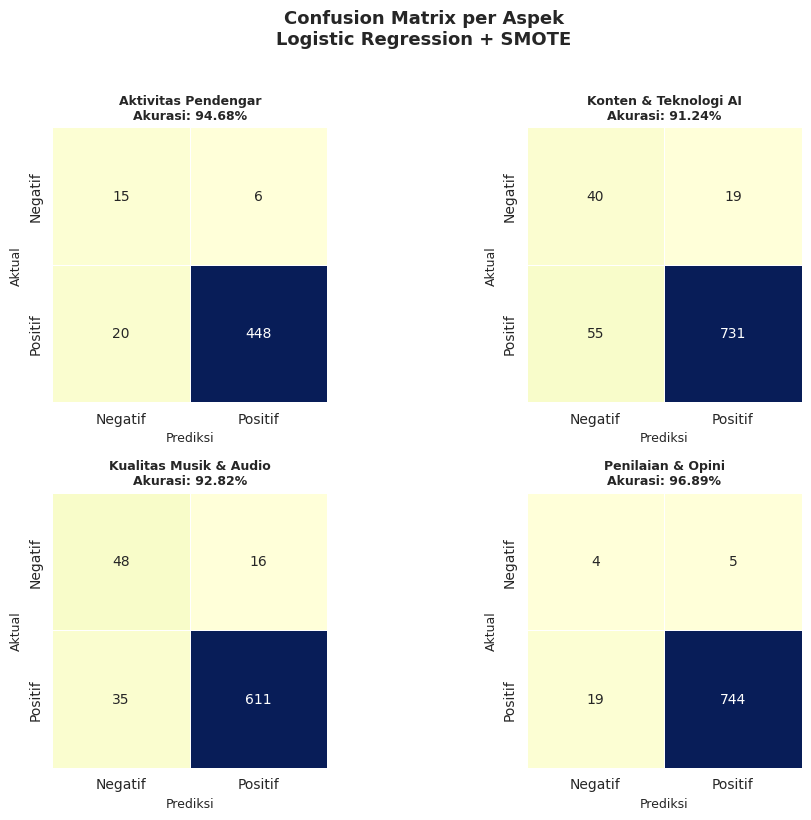

✅ confusion_matrix_per_aspek.png tersimpan dengan format 2 baris


In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# CELL 5: CONFUSION MATRIX PER ASPEK (2 BARIS)

label_indo = ['Negatif', 'Positif']
n_aspek = len(hasil_smote)

# Tentukan jumlah kolom berdasarkan target 2 baris
n_rows = 2
n_cols = math.ceil(n_aspek / n_rows)

# Buat subplot dengan format grid (n_rows x n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Meratakan axes menjadi 1D agar mudah di-loop dengan indeks
axes_flat = axes.flatten()

for i, (aspek, hasil) in enumerate(hasil_smote.items()):
    ax = axes_flat[i]
    sns.heatmap(
        hasil['cm'],
        annot=True, fmt='d', cmap='YlGnBu',
        cbar=False,
        xticklabels=label_indo,
        yticklabels=label_indo,
        ax=ax, square=True, linewidths=0.5
    )
    ax.set_title(
        f"{aspek}\nAkurasi: {hasil['test_acc']*100:.2f}%",
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)

# Menyembunyikan sisa kotak subplot yang kosong (jika jumlah aspek ganjil)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle(
    'Confusion Matrix per Aspek\nLogistic Regression + SMOTE',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrix_per_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ confusion_matrix_per_aspek.png tersimpan dengan format 2 baris")

**Visualisasi Tabel Classification Report per Aspek**


In [ ]:
# CELL 6: CLASSIFICATION REPORT PER ASPEK

label_order       = ['negative', 'positive']
ringkasan_lengkap = []

print("=== CLASSIFICATION REPORT PER ASPEK (SMOTE) ===\n")

for aspek, hasil in hasil_smote.items():
    print(f"--- {aspek} ---")
    report = hasil['report']

    df_report = pd.DataFrame({
        'Kelas'    : ['Negatif', 'Positif', 'Macro Avg', 'Weighted Avg'],
        'Precision': [
            round(report['negative']['precision'], 4),
            round(report['positive']['precision'], 4),
            round(report['macro avg']['precision'], 4),
            round(report['weighted avg']['precision'], 4),
        ],
        'Recall'   : [
            round(report['negative']['recall'], 4),
            round(report['positive']['recall'], 4),
            round(report['macro avg']['recall'], 4),
            round(report['weighted avg']['recall'], 4),
        ],
        'F1-Score' : [
            round(report['negative']['f1-score'], 4),
            round(report['positive']['f1-score'], 4),
            round(report['macro avg']['f1-score'], 4),
            round(report['weighted avg']['f1-score'], 4),
        ],
        'Support'  : [
            int(report['negative']['support']),
            int(report['positive']['support']),
            int(report['macro avg']['support']),
            int(report['weighted avg']['support']),
        ],
    })

    styled = df_report.style\
        .background_gradient(
            cmap='Blues',
            subset=['Precision', 'Recall', 'F1-Score']
        )\
        .format({
            'Precision': '{:.4f}',
            'Recall'   : '{:.4f}',
            'F1-Score' : '{:.4f}',
            'Support'  : '{:.0f}'
        })\
        .set_caption(f"Classification Report - {aspek}")
    display(styled)

    ringkasan_lengkap.append({
        'Aspek'        : aspek,
        'Akurasi Test' : round(hasil['test_acc'], 4),
        'Precision (M)': round(report['macro avg']['precision'], 4),
        'Recall (M)'   : round(report['macro avg']['recall'], 4),
        'F1-Score (M)' : round(report['macro avg']['f1-score'], 4),
        'Precision (W)': round(report['weighted avg']['precision'], 4),
        'Recall (W)'   : round(report['weighted avg']['recall'], 4),
        'F1-Score (W)' : round(report['weighted avg']['f1-score'], 4),
    })

=== CLASSIFICATION REPORT PER ASPEK (SMOTE) ===

--- Aktivitas Pendengar ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.4286,0.7143,0.5357,21
1,Positif,0.9868,0.9573,0.9718,468
2,Macro Avg,0.7077,0.8358,0.7538,489
3,Weighted Avg,0.9628,0.9468,0.9531,489


--- Konten & Teknologi AI ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.4211,0.6780,0.5195,59
1,Positif,0.9747,0.9300,0.9518,786
2,Macro Avg,0.6979,0.8040,0.7357,845
3,Weighted Avg,0.9360,0.9124,0.9216,845


--- Kualitas Musik & Audio ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.5783,0.7500,0.6531,64
1,Positif,0.9745,0.9458,0.9599,646
2,Macro Avg,0.7764,0.8479,0.8065,710
3,Weighted Avg,0.9388,0.9282,0.9323,710


--- Penilaian & Opini ---


,Kelas,Precision,Recall,F1-Score,Support
0,Negatif,0.1739,0.4444,0.2500,9
1,Positif,0.9933,0.9751,0.9841,763
2,Macro Avg,0.5836,0.7098,0.6171,772
3,Weighted Avg,0.9838,0.9689,0.9756,772


In [ ]:
# CELL 7: RINGKASAN DAN TOTAL EVALUASI KESELURUHAN

df_ringkasan = pd.DataFrame(ringkasan_lengkap)

# Tabel ringkasan per aspek
print("=== RINGKASAN EVALUASI PER ASPEK (SMOTE) ===\n")
styled_ringkasan = df_ringkasan.style\
    .background_gradient(
        cmap='Blues',
        subset=['Akurasi Test', 'Precision (W)', 'Recall (W)', 'F1-Score (W)']
    )\
    .format({col: '{:.4f}' for col in df_ringkasan.columns if col != 'Aspek'})\
    .set_caption("Ringkasan Evaluasi per Aspek - SMOTE")
display(styled_ringkasan)

# Label-based accuracy per aspek
print("\n=== LABEL-BASED ACCURACY PER ASPEK ===")
semua_acc = []
for _, row in df_ringkasan.iterrows():
    acc = row['Akurasi Test']
    semua_acc.append(acc)
    print(f"  {row['Aspek']:<35} : {acc:.4f} ({acc*100:.2f}%)")

rata_rata = np.mean(semua_acc)
print(f"\n  {'Label-Based Accuracy (rata-rata)':<35} : {rata_rata:.4f} ({rata_rata*100:.2f}%)")

# Total evaluasi keseluruhan
print(f"\n=== TOTAL EVALUASI KESELURUHAN MODEL (SMOTE) ===\n")
total = {
    'Akurasi'      : round(df_ringkasan['Akurasi Test'].mean(), 4),
    'Precision (W)': round(df_ringkasan['Precision (W)'].mean(), 4),
    'Recall (W)'   : round(df_ringkasan['Recall (W)'].mean(), 4),
    'F1-Score (W)' : round(df_ringkasan['F1-Score (W)'].mean(), 4),
    'Precision (M)': round(df_ringkasan['Precision (M)'].mean(), 4),
    'Recall (M)'   : round(df_ringkasan['Recall (M)'].mean(), 4),
    'F1-Score (M)' : round(df_ringkasan['F1-Score (M)'].mean(), 4),
}
for metrik, nilai in total.items():
    print(f"  {metrik:<20} : {nilai:.4f} ({nilai*100:.2f}%)" if 'Akurasi' in metrik
          else f"  {metrik:<20} : {nilai:.4f}")

df_total = pd.DataFrame([{'Metrik': 'Keseluruhan Model', **total}])
styled_total = df_total.style\
    .background_gradient(
        cmap='Greens',
        subset=['Akurasi', 'Precision (W)', 'Recall (W)', 'F1-Score (W)']
    )\
    .format({col: '{:.4f}' for col in df_total.columns if col != 'Metrik'})\
    .set_caption("Total Evaluasi Keseluruhan Model - SMOTE")
display(styled_total)

=== RINGKASAN EVALUASI PER ASPEK (SMOTE) ===



,Aspek,Akurasi Test,Precision (M),Recall (M),F1-Score (M),Precision (W),Recall (W),F1-Score (W)
0,Aktivitas Pendengar,0.9468,0.7077,0.8358,0.7538,0.9628,0.9468,0.9531
1,Konten & Teknologi AI,0.9124,0.6979,0.8040,0.7357,0.9360,0.9124,0.9216
2,Kualitas Musik & Audio,0.9282,0.7764,0.8479,0.8065,0.9388,0.9282,0.9323
3,Penilaian & Opini,0.9689,0.5836,0.7098,0.6171,0.9838,0.9689,0.9756



=== LABEL-BASED ACCURACY PER ASPEK ===
  Aktivitas Pendengar                 : 0.9468 (94.68%)
  Konten & Teknologi AI               : 0.9124 (91.24%)
  Kualitas Musik & Audio              : 0.9282 (92.82%)
  Penilaian & Opini                   : 0.9689 (96.89%)

  Label-Based Accuracy (rata-rata)    : 0.9391 (93.91%)

=== TOTAL EVALUASI KESELURUHAN MODEL (SMOTE) ===

  Akurasi              : 0.9391 (93.91%)
  Precision (W)        : 0.9554
  Recall (W)           : 0.9391
  F1-Score (W)         : 0.9456
  Precision (M)        : 0.6914
  Recall (M)           : 0.7994
  F1-Score (M)         : 0.7283


,Metrik,Akurasi,Precision (W),Recall (W),F1-Score (W),Precision (M),Recall (M),F1-Score (M)
0,Keseluruhan Model,0.9391,0.9554,0.9391,0.9456,0.6914,0.7994,0.7283


Simpan Hasil

In [ ]:
# CELL 8: SIMPAN HASIL

df_ringkasan.to_csv('Evaluasi_SMOTE.csv', encoding='utf-8-sig', index=False)
print("✅ File tersimpan:")
print("   Evaluasi_SMOTE.csv")
print("   confusion_matrix_per_aspek.png  (dari Cell 5)")

from google.colab import files
files.download('Evaluasi_SMOTE.csv')

✅ File tersimpan:
   Evaluasi_SMOTE.csv
   confusion_matrix_per_aspek.png  (dari Cell 5)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>